# Three ways to cut the seed template, ranked by `chromatin_od` -- 49 ROIs x 3 clicks

**Question.** How much does the choice of seed-template refinement change precision in the top 10, 20
and 30 candidates, when every other part of the production configuration is held fixed?
`bbox_refinement_three_way_chromatin_od.ipynb` (committed in `0982979`) asked this on 14 ROIs with one
click each. This notebook re-runs **the same analysis on 49 ROIs x 3 distinct clicks per ROI**.
Nothing else about the analysis changes.

| condition | template size | template centre | what it is |
|---|---|---|---|
| `default_51` | 51 px (`tm.BASE_SIZE`, the MIDOG++ annotation box) | the click | untightened -- `FSConfig.base_size`'s default, no Otsu step |
| `gray_bbox` | Otsu component's longer side, on `gray_inverted` | component's bbox centre | `ss.tightened_template_box` -- what `build_seed` does in production today (D8) |
| `hem_bbox` | Otsu component's longer side, on `hematoxylin_od` | component's bbox centre | the same function, fed the search channel instead |

**What stays the same** as the 14-ROI notebook:
- *Only the template's size and centre change between conditions.* The search channel is
  `hematoxylin_od` (D3) for all three, and so is the `chromatin_od` statistic (`od51`, a fixed 51 px
  window).
- *The pipeline is the shipping entry point.* Every run is
  `production.run_production_pipeline(rgb, seed, mpp, rank_key="chromatin_od")`, with no overrides:
  `TM_CCOEFF` (D1), `hematoxylin_od` (D3), deep floor z = -1.5, `MAX_PEAKS = 100` (D9), NMS radius =
  match radius = 7.5 um (D7), and 5 px self-hit removal at the template centre (D8 cost 1).
- *Scoring.* `evaluate.bucket_detections` against all annotations of the image minus that click's own
  annotation. TP@K counts `human_correct_label` in the top K; precision@K = TP@K / K, for K = 10, 20, 30.
- *The joint click gate.* A draw from `agreement_pool` then `border_filter(pool, 36, shape)` is
  accepted only if `tightened_template_box` succeeds on both `gray_inverted` and `hematoxylin_od` and all
  three templates' 73 px patches are readable at their own centres. A refused draw is recorded with the
  condition(s) that refused it, and the walk redraws on the same RNG stream.

**What changes:**
- *ROIs.* All 14 `images/extra_valid/*.tiff` (`original_14`) plus all 35
  `images/extra_valid/testing_set/*.tiff` (`testing_35`), 7 per tumour domain. The effect was first seen
  on `original_14` at seed 0, so `testing_35` is the out-of-sample, confirmatory check. `all_49` is the
  primary Holm family because it is the larger sample, but it contains that hypothesis-generating draw,
  so it is not out-of-sample.
- *Three distinct clicks per ROI.* Seed `s` in (0, 1, 2) walks its own RNG stream
  `[s, image_id]` under the joint gate. Before seed `s` walks, the annotations accepted by seeds
  `< s` are removed from the pool, so the three clicks are different annotations. Seed 0 has nothing
  removed, so it is exactly the 14-ROI notebook's draw. Gate A checks that.
- *The ROI is the unit (D5).* Per ROI, pair and K, the statistic is the integer delta summed over the
  three clicks, `sum_s (TP_a - TP_b)`.
  - **Test:** an exact two-sided sign-flip over the ROIs, computed by dynamic-programming convolution
    (2^49 sign patterns can't be enumerated). It is validated against the 14-ROI notebook's own p-values
    and cross-checked by a seeded Monte Carlo sign-flip.
  - **Multiplicity:** Holm over the 9 (pair, K) tests, on `all_49` (primary) and separately on
    `testing_35`.
  - **Effect size:** a cluster bootstrap that resamples whole ROIs, keeping each ROI's three clicks
    together, gives a 95% percentile CI for each pooled-precision delta.
  - **D5's CI-and-majority criterion,** per pair and K: the CI excludes 0 **and** a majority of the
    ROIs move in the same direction. This is the clause of D5's bar this design can apply. D5's full
    bar also asks for 5 seeds on the 14 `extra_valid` ROIs, read at recall@K (D4); this run is 3 clicks
    on 49 ROIs, read at precision@K.

**Scope and caveats carried in from the 14-ROI notebook:**
- one ranking axis, `chromatin_od`; nothing here carries over to `tm_score`;
- K <= 30 only; D9 validated `MAX_PEAKS = 100` with `tm_score` ranking, not `chromatin_od`;
- the clicks come from the joint gate, not from each condition's own production draw (Table A counts
  where that differs). That is the design: the question is which template refinement is best, so all
  three templates are cut at the same click and only the template differs;
- the Otsu window is 51 px, so a tightened box can never be larger than `default_51`.

**Added after the audit** (`Research Logs/2026-09-17-bbox-refinement-three-way-chromatin-od-49roi-3seed-audit.md`),
and not part of the prompt's pre-specified analysis:
- a t interval next to the bootstrap CI, and a robustness label on D5's CI-and-majority criterion;
- post-hoc sensitivities: recall@K weighting, the worst of each ROI's three clicks, the domain as the
  unit, and a human/canine split.

**Shelf life.** D10 (`DECISIONS.md`, 2026-09-17, decided but not applied when this ran) replaces the
5 px self-hit filter with a seed mask one NMS radius wide, and removes `prod.SELF_HIT_RADIUS` and
`n_self_hits`, which this notebook reads. D10 says `chromatin_od` comparisons must not straddle the
change. Once D10 is applied, this notebook no longer runs as written, and its numbers should not be
mixed with post-D10 numbers.

In [1]:
import gc
import hashlib
import itertools
import math
import os
import sys
import time
from fractions import Fraction

import cv2
import numpy as np
import pandas as pd
from scipy import stats as sps

sys.path.insert(0, '..')
from midog_utils import channels as ch
from midog_utils import dataset as ds
from midog_utils import evaluate as ev
from midog_utils import invariants as inv
from midog_utils import production as prod
from midog_utils import seed_selection as ss
from midog_utils import template_match as tm

pd.set_option('display.width', 250)
pd.set_option('display.max_columns', 80)
pd.set_option('display.max_rows', 400)
pd.set_option('display.max_colwidth', 140)

NB_T0 = time.time()

# subset -> directory. Each is listed non-recursively: a recursive glob over extra_valid/ would mix the two sets.
SUBSET_DIRS = {'original_14': '../images/extra_valid', 'testing_35': '../images/extra_valid/testing_set'}
SUBSET_SIZES = {'original_14': 14, 'testing_35': 35}
N_DOMAINS = 7
N_PER_DOMAIN = 7
DB_PATH = '../databases/MIDOG++.json'
SEED_INDICES = (0, 1, 2)            # three distinct clicks per ROI; seed s walks RNG stream [s, image_id]

# condition -> the channel its Otsu tightening runs on; None = no tightening, 51 px box on the click.
CONDITIONS = {'default_51': None, 'gray_bbox': 'gray_inverted', 'hem_bbox': 'hematoxylin_od'}
# (a, b) -> every delta below is a minus b.
PAIRS = [('gray_bbox', 'default_51'), ('hem_bbox', 'default_51'), ('hem_bbox', 'gray_bbox')]

RANK_KEY = 'chromatin_od'
BUDGETS = (10, 20, 30)

DEFAULT_BASE_SIZE = tm.BASE_SIZE    # 51
OTSU_WINDOW = tm.BASE_SIZE          # 51 -- a tightened box can never exceed this
PATCH_SIZE = tm.PATCH_SIZE          # 73, rotation-safe read around a template centre
BORDER = PATCH_SIZE // 2            # 36

# The production settings are read from midog_utils.production, then checked against the values the 14-ROI notebook ran with.
REFERENCE_CONFIG = dict(CHANNEL='hematoxylin_od', TM_METHOD=cv2.TM_CCOEFF, PEAK_MIN_DISTANCE=7, SELF_HIT_RADIUS=5.0, DEEP_FLOOR_Z=-1.5, MAX_PEAKS=100, OD_WINDOW=51)
CONFIG_DRIFT = pd.DataFrame([dict(setting=k, production_py=getattr(prod, k), reference_notebook=v, match=getattr(prod, k) == v) for k, v in REFERENCE_CONFIG.items()])
print(CONFIG_DRIFT.to_string(index=False))
assert CONFIG_DRIFT['match'].all(), 'midog_utils.production no longer matches the configuration the 14-ROI notebook ran at'
assert ev.MIDOG_RADIUS_UM == 7.5, 'D7: NMS radius = match radius = 7.5 um'
MAX_PEAKS = prod.MAX_PEAKS
SELF_HIT_RADIUS = prod.SELF_HIT_RADIUS

# statistics
SUBSETS = ('all_49', 'original_14', 'testing_35')
HOLM_FAMILIES = ('all_49', 'testing_35')    # all_49 is primary (larger, but holds the hypothesis-generating draw); testing_35 is the out-of-sample, confirmatory check
N_BOOT = 10_000
BOOT_SEED = 20260916
N_MC = 200_000
MC_SEED = 20260917

# the committed 14-ROI run: read for Gate A and for validating the sign-flip test, never written
REF_STEM = '../results/precision_at_k_14roi_prodseed_chromatin_bbox3way'
REF_PER_ROI = f'{REF_STEM}_per_roi.csv'
REF_TOP = f'{REF_STEM}_top30.csv'
REF_DELTA_PER_ROI = f'{REF_STEM}_delta_per_roi.csv'
REF_DELTA_STATS = f'{REF_STEM}_delta_stats.csv'

OUT_STEM = '../results/precision_at_k_49roi_3seed_chromatin_bbox3way'
OUT = {name: f'{OUT_STEM}_{name}.csv' for name in ('per_run', 'per_roi', 'summary', 'by_domain', 'by_seed', 'delta_per_roi', 'delta_stats', 'bootstrap_ci', 'contested_sensitivity', 'post_hoc_sensitivity', 'top30', 'verification')}
# the scanner column of the two image manifests, read for the species x scanner table only
MANIFESTS = {'original_14': '../images/extra_valid/MANIFEST.md', 'testing_35': '../images/extra_valid/testing_set/MANIFEST.md'}
FIG_STEM = 'bbox3way_49roi3seed'
assert not any(os.path.abspath(p).startswith(os.path.abspath(REF_STEM) + '_') for p in OUT.values()), 'an output path would overwrite the committed 14-ROI run'

print(f'\n{sum(SUBSET_SIZES.values())} ROIs ({N_PER_DOMAIN} per domain x {N_DOMAINS} domains) x {len(SEED_INDICES)} clicks x {len(CONDITIONS)} conditions, ranked by {RANK_KEY}, K = {BUDGETS}, MAX_PEAKS = {MAX_PEAKS}')
print(f'cluster bootstrap B = {N_BOOT} (seed {BOOT_SEED}); Monte Carlo sign-flip {N_MC} draws (seed {MC_SEED}); Holm families {HOLM_FAMILIES}')

          setting  production_py reference_notebook  match
          CHANNEL hematoxylin_od     hematoxylin_od   True
        TM_METHOD              4                  4   True
PEAK_MIN_DISTANCE              7                  7   True
  SELF_HIT_RADIUS            5.0                5.0   True
     DEEP_FLOOR_Z           -1.5               -1.5   True
        MAX_PEAKS            100                100   True
        OD_WINDOW             51                 51   True

49 ROIs (7 per domain x 7 domains) x 3 clicks x 3 conditions, ranked by chromatin_od, K = (10, 20, 30), MAX_PEAKS = 100
cluster bootstrap B = 10000 (seed 20260916); Monte Carlo sign-flip 200000 draws (seed 20260917); Holm families ('all_49', 'testing_35')


## The clicks and the run

Per ROI:
1. Load the pixels and convert `gray_inverted` and `hematoxylin_od` **once**.
2. Build the seed pool the way `build_seed` does (`agreement_pool`, then `border_filter` at 36 px).
3. Evaluate every condition's template spec on every pool annotation. The gate is deterministic, so this
   gives both the joint-valid pool size and a cache the three walks read instead of re-running Otsu.
4. Walk seeds 0, 1, 2 in order, each on its own `[s, image_id]` stream. Seed `s` walks the pool minus the
   annotations seeds `< s` accepted. A removed annotation is not a refusal and is not listed in
   `refused_draws`. While the channels are still in memory, record a SHA-1 of each condition's exact
   template pixels (cut the way `find_and_suppress` cuts it) for Gate B.
5. Free the channels, then run the 9 (click, condition) pipeline calls against the same RGB array.
   `run_production_pipeline` converts `hematoxylin_od` itself on every call; that is the shipping entry
   point, left unchanged.

Scoring: `evaluate.bucket_detections` greedily matches the full ranked list to that click's `gt_eval` in
rank order, and TP@K counts `human_correct_label` in the top K. Matching goes best-rank-first, so which
annotations the top K claim never depends on anything ranked below K.

`per_run` and `top30` are rewritten after every ROI, so a halt later in the notebook keeps the pipeline
output.

In [2]:
def roi_table(subset_dirs=SUBSET_DIRS):
    """
        Every ROI TIFF in each subset directory, listed non-recursively.

        subset_dirs (dict): subset name -> directory holding that subset's TIFFs.

        Returns pd.DataFrame: one row per file, with subset, file_name and path.
    """
    return pd.DataFrame([dict(subset=subset, file_name=fn, path=f'{d}/{fn}') for subset, d in subset_dirs.items() for fn in sorted(f for f in os.listdir(d) if f.endswith('.tiff'))])


def template_spec(condition, channels, cx, cy):
    """
        The template size and centre one condition cuts for one click.

        condition (str): a key of CONDITIONS.
        channels (dict): channel name -> this ROI's converted single-channel image.
        cx (float): click x, full-image pixels.
        cy (float): click y, full-image pixels.

        Returns tuple[int, float, float] or None: (base_size, template x, template y), or None if the Otsu gate refuses the click or the rotation-safe patch can't be read at the template centre.
    """
    tighten_channel = CONDITIONS[condition]
    spec = (DEFAULT_BASE_SIZE, cx, cy) if tighten_channel is None else ss.tightened_template_box(channels[tighten_channel], cx, cy, otsu_window=OTSU_WINDOW)
    if spec is None or tm.read_padded_patch(channels['hematoxylin_od'], spec[1], spec[2], PATCH_SIZE) is None:
        return None
    return int(spec[0]), float(spec[1]), float(spec[2])


def template_digest(hem, base_size, tx, ty):
    """
        A digest of the exact template pixels find_and_suppress cuts for one condition.

        hem (np.ndarray): this ROI's hematoxylin_od channel, the search channel.
        base_size (int): the template side length.
        tx (float): template centre x.
        ty (float): template centre y.

        Returns str: SHA-1 of the float32 template bytes.
    """
    templates, _ = tm.build_augmentations(tm.read_padded_patch(hem, tx, ty, PATCH_SIZE), base_size, (1.0,), 1, (False,))
    return hashlib.sha1(np.ascontiguousarray(templates[0], dtype=np.float32).tobytes()).hexdigest()


def pool_gate_specs(pool, channels):
    """
        Every condition's template spec for every annotation in the border-filtered pool.

        pool (pd.DataFrame): agreement-tier, border-filtered mitotic annotations.
        channels (dict): channel name -> this ROI's converted single-channel image.

        Returns dict: ann_id -> {condition: (base_size, x, y) or None}.
    """
    return {int(row['ann_id']): {condition: template_spec(condition, channels, float(row['cx']), float(row['cy'])) for condition in CONDITIONS} for _, row in pool.iterrows()}


def draw_joint_click(pool, rng, gate_specs):
    """
        Draw one click every condition can build a template from, redrawing on the same RNG stream after a refusal.

        pool (pd.DataFrame): the border-filtered pool, minus the clicks earlier seeds accepted.
        rng (np.random.Generator): this seed's [seed_index, image_id] stream.
        gate_specs (dict): ann_id -> condition -> spec, from pool_gate_specs.

        Returns tuple[pd.Series, dict, list[str]]: the accepted annotation, condition -> (base_size, x, y), and one "ann_id:refusing+conditions" entry per refused draw, in draw order.
    """
    working, refusals = pool.copy(), []
    while len(working) > 0:
        idx = int(rng.integers(len(working)))
        row = working.iloc[idx]
        specs = gate_specs[int(row['ann_id'])]
        if all(spec is not None for spec in specs.values()):
            return row, specs, refusals
        refusals.append(f"{int(row['ann_id'])}:{'+'.join(c for c, spec in specs.items() if spec is None)}")
        working = working.drop(working.index[idx])
    raise ValueError('seed pool exhausted -- no annotation passed every condition')


def score_top_k(detections, gt_eval, match_radius):
    """
        Match a ranked detection list to ground truth and count true positives in each top-K.

        detections (pd.DataFrame): ranked detections, best first.
        gt_eval (pd.DataFrame): ground truth with the click's own annotation removed.
        match_radius (float): match radius in pixels.

        Returns tuple[pd.DataFrame, dict]: the detections with match buckets added, and K -> true positives in the top K.
    """
    det_out, _ = ev.bucket_detections(detections, gt_eval, match_radius)
    hit = (det_out['bucket'] == ev.HUMAN_CORRECT_LABEL).to_numpy()
    return det_out, {k: int(hit[:k].sum()) for k in BUDGETS}


def run_roi(roi, annotations):
    """
        Draw three distinct joint clicks on one ROI, then run the production pipeline once per (click, condition).

        roi (pd.Series): one ROIS row (subset, file_name, path, image_id, domain).
        annotations (pd.DataFrame): the full MIDOG++ annotation table.

        Returns tuple[list[dict], list[pd.DataFrame]]: one result row per (seed, condition), and each run's top-max(BUDGETS) scored detections.
    """
    fn, image_id = roi['file_name'], int(roi['image_id'])
    rgb = ds.load_roi(roi['path'])
    mpp = ds.roi_mpp(roi['path'])
    channels = {name: ch.to_channel(rgb, name) for name in ('gray_inverted', 'hematoxylin_od')}  # once per ROI, shared by all three draws

    gt = ds.image_annotations(annotations, fn)
    pool, flagged = ss.agreement_pool(gt[gt['category_id'] == ds.MITOTIC])
    n_agreement = len(pool)
    pool = ss.border_filter(pool, BORDER, rgb.shape)
    gate_specs = pool_gate_specs(pool, channels)
    n_joint_valid = sum(all(spec is not None for spec in specs.values()) for specs in gate_specs.values())
    if n_joint_valid < len(SEED_INDICES):
        raise ValueError(f'{fn}: only {n_joint_valid} pool annotations pass the joint gate, fewer than the {len(SEED_INDICES)} distinct clicks needed')

    draws, accepted = [], []
    for seed_index in SEED_INDICES:
        seed_pool = pool[~pool['ann_id'].isin(accepted)] if accepted else pool  # seed 0 walks the untouched pool
        rng = np.random.default_rng([seed_index, image_id])
        ann, specs, refusals = draw_joint_click(seed_pool, rng, gate_specs)
        digests = {condition: template_digest(channels['hematoxylin_od'], *spec) for condition, spec in specs.items()}
        draws.append((seed_index, ann, specs, refusals, len(seed_pool), digests))
        accepted.append(int(ann['ann_id']))
    del channels
    gc.collect()

    match_radius = ev.radius_px(mpp)
    rows, tops = [], []
    for seed_index, ann, specs, refusals, n_seed_pool, digests in draws:
        click_xy = (float(ann['cx']), float(ann['cy']))
        seed_ann_id = int(ann['ann_id'])
        gt_eval = gt[gt['ann_id'] != seed_ann_id].reset_index(drop=True)  # D8 cost 3: ground truth stays keyed to the click
        n_gt = int((gt_eval['category_id'] == ds.MITOTIC).sum())
        nearest_other = float(np.hypot(gt_eval['cx'] - click_xy[0], gt_eval['cy'] - click_xy[1]).min())
        line = []
        for condition, (base_size, tx, ty) in specs.items():
            offset = float(np.hypot(tx - click_xy[0], ty - click_xy[1]))
            seed = ss.Seed(ann_id=seed_ann_id, click_xy=click_xy, template_xy=(tx, ty), base_size=base_size, recentred=CONDITIONS[condition] is not None, offset_px=offset, n_retries=len(refusals), agreement_flagged=bool(flagged), n_agreement_pool=n_agreement, n_after_border=len(pool))
            t0 = time.time()
            detections, info = prod.run_production_pipeline(rgb, seed, mpp, rank_key=RANK_KEY)
            det_out, tp = score_top_k(detections, gt_eval, match_radius)

            # the seed annulus: anything left within one match radius of the click (whose annotation is not in gt_eval)
            d_click = np.hypot(det_out['cx'] - click_xy[0], det_out['cy'] - click_xy[1]).to_numpy()
            d_tpl = np.hypot(det_out['cx'] - tx, det_out['cy'] - ty).to_numpy()
            near = np.flatnonzero(d_click <= match_radius)
            near_detail = ';'.join(f"rank{int(det_out['rank'].iat[i])}:{det_out['bucket'].iat[i]}:ann{int(det_out['matched_ann_id'].iat[i])}:d_click={d_click[i]:.1f}:d_tpl={d_tpl[i]:.1f}" for i in near)
            od = det_out['od'].to_numpy()
            rows.append(dict(subset=roi['subset'], file_name=fn, domain=roi['domain'], image_id=image_id, seed_index=seed_index, condition=condition, seed_ann_id=seed_ann_id, click_cx=click_xy[0], click_cy=click_xy[1], base_size=int(base_size), tpl_cx=tx, tpl_cy=ty, tpl_offset_px=round(offset, 3), tpl_sha1=digests[condition], n_agreement_pool=n_agreement, n_after_border=len(pool), n_joint_valid=n_joint_valid, n_seed_pool=n_seed_pool, n_retries=len(refusals), refused_draws=';'.join(refusals), contested_seed_tier=bool(flagged), n_gt_mitotic=n_gt, nearest_other_ann_px=round(nearest_other, 2), n_peaks=int(info['n_peaks']), max_peaks_binding=bool(info['max_peaks_binding']), n_detections=int(info['n_detections']), n_self_hits=int(info['n_self_hits']), n_near_click=len(near), near_click_detail=near_detail, od_nan=int(np.isnan(od).sum()), od_descending=bool(np.all(np.diff(od) <= 0)), match_radius_px=match_radius, mpp=mpp, t_pipeline_s=round(time.time() - t0, 1), **{f'tp_at_{k}': tp[k] for k in BUDGETS}))
            tops.append(det_out.head(max(BUDGETS)).assign(subset=roi['subset'], file_name=fn, seed_index=seed_index, condition=condition))
            line.append(f"{condition} base={base_size:2d} off={offset:4.1f} n_det={info['n_detections']:3d} tp={tuple(tp.values())}")
        print(f"  [{fn} s{seed_index}] ann={seed_ann_id} retries={len(refusals)} | " + ' | '.join(line), flush=True)

    del rgb
    gc.collect()
    return rows, tops


print({subset: len(os.listdir(d)) for subset, d in SUBSET_DIRS.items()}, '(directory entries, before filtering to .tiff)')

{'original_14': 16, 'testing_35': 36} (directory entries, before filtering to .tiff)


In [3]:
images, annotations = ds.load_annotations(DB_PATH)
# the two dataset conventions this notebook relies on (formerly dataset.check_invariants, removed by the production cleanup)
assert ((annotations['w'] == ds.BOX_SIZE) & (annotations['h'] == ds.BOX_SIZE)).all(), f'an annotation box is not {ds.BOX_SIZE}x{ds.BOX_SIZE}'
assert set(annotations['category_id'].unique()) <= {ds.MITOTIC, ds.LOOKALIKE}, 'unexpected annotation category id'
assert not images['file_name'].duplicated().any(), 'a file name appears twice in the annotation DB'
meta_ix = images.set_index('file_name')[['image_id', 'tumor_type']]

ROIS = roi_table()
missing = sorted(set(ROIS['file_name']) - set(meta_ix.index))
assert not missing, f'.tiff on disk absent from the annotation DB: {missing}'
assert not ROIS['file_name'].duplicated().any(), f"file name in both subsets: {sorted(ROIS.loc[ROIS['file_name'].duplicated(), 'file_name'])}"
assert ROIS['subset'].value_counts().to_dict() == SUBSET_SIZES, f"expected {SUBSET_SIZES}, found {ROIS['subset'].value_counts().to_dict()}"
ROIS['image_id'] = ROIS['file_name'].map(meta_ix['image_id']).astype(int)
ROIS['domain'] = ROIS['file_name'].map(meta_ix['tumor_type'])
per_domain = ROIS.groupby('domain').size()
assert len(ROIS) == sum(SUBSET_SIZES.values()) == N_DOMAINS * N_PER_DOMAIN and len(per_domain) == N_DOMAINS and (per_domain == N_PER_DOMAIN).all(), f'expected {N_PER_DOMAIN} ROIs in each of {N_DOMAINS} domains:\n{per_domain}'
ROIS = ROIS.sort_values(['domain', 'subset', 'file_name']).reset_index(drop=True)
print(ROIS.groupby(['domain', 'subset']).size().unstack('subset').assign(total=lambda t: t.sum(axis=1)).to_string())

t_run = time.time()
result_rows, top_frames = [], []
for i, roi in ROIS.iterrows():
    t_roi = time.time()
    rows, tops = run_roi(roi, annotations)
    result_rows.extend(rows)
    top_frames.extend(tops)
    pd.DataFrame(result_rows).to_csv(OUT['per_run'], index=False)  # persisted per ROI so a later halt keeps the pipeline output
    pd.concat(top_frames, ignore_index=True).to_csv(OUT['top30'], index=False)
    print(f"[{i + 1}/{len(ROIS)} {roi['file_name']}] {roi['subset']}, {roi['domain']}: joint-valid pool {rows[0]['n_joint_valid']} [{time.time() - t_roi:.0f}s; {(time.time() - t_run) / 60:.1f} min so far]", flush=True)

RESULTS = pd.DataFrame(result_rows)
TOP = pd.concat(top_frames, ignore_index=True)
TOP.to_csv(OUT['top30'], index=False)
ROI_ORDER = ROIS['file_name'].tolist()
ROI_META = ROIS.set_index('file_name')
RUNTIME_LOOP_MIN = (time.time() - t_run) / 60
print(f"\n{len(ROIS)} ROIs x {len(SEED_INDICES)} clicks x {len(CONDITIONS)} conditions = {len(RESULTS)} pipeline runs; the run loop (pixel loads, channel conversion, joint gate, pipeline calls, scoring) took {RUNTIME_LOOP_MIN:.1f} min, of which the pipeline calls sum to {RESULTS['t_pipeline_s'].sum() / 60:.1f} min (per call: median {RESULTS['t_pipeline_s'].median():.1f}s, max {RESULTS['t_pipeline_s'].max():.1f}s; one wall-clock run on this machine); top-{max(BUDGETS)} lists -> {OUT['top30']}")

subset                            original_14  testing_35  total
domain                                                          
canine cutaneous mast cell tumor            2           5      7
canine lung cancer                          2           5      7
canine lymphosarcoma                        2           5      7
canine soft tissue sarcoma                  2           5      7
human breast cancer                         2           5      7
human melanoma                              2           5      7
human neuroendocrine tumor                  2           5      7


  [300.tiff s0] ann=14499 retries=1 | default_51 base=51 off= 0.0 n_det= 99 tp=(9, 19, 27) | gray_bbox base=49 off= 2.5 n_det= 99 tp=(9, 19, 27) | hem_bbox base=25 off= 4.1 n_det= 99 tp=(8, 17, 27)


  [300.tiff s1] ann=14578 retries=1 | default_51 base=51 off= 0.0 n_det= 99 tp=(9, 19, 27) | gray_bbox base=27 off= 3.6 n_det= 97 tp=(10, 19, 29) | hem_bbox base=21 off= 3.2 n_det= 95 tp=(10, 19, 26)


  [300.tiff s2] ann=14553 retries=1 | default_51 base=51 off= 0.0 n_det= 99 tp=(9, 18, 27) | gray_bbox base=43 off= 2.5 n_det= 99 tp=(10, 19, 28) | hem_bbox base=25 off= 2.2 n_det= 99 tp=(10, 18, 27)


[1/49 300.tiff] original_14, canine cutaneous mast cell tumor: joint-valid pool 99 [30s; 0.5 min so far]


...

  [404.tiff s0] ann=20471 retries=0 | default_51 base=51 off= 0.0 n_det= 98 tp=(4, 8, 11) | gray_bbox base=43 off= 0.5 n_det= 96 tp=(4, 8, 11) | hem_bbox base=39 off= 1.8 n_det= 96 tp=(4, 7, 11)


  [404.tiff s1] ann=20474 retries=0 | default_51 base=51 off= 0.0 n_det= 98 tp=(4, 7, 9) | gray_bbox base=43 off= 6.0 n_det= 97 tp=(3, 6, 9) | hem_bbox base=31 off= 2.2 n_det= 97 tp=(3, 6, 8)


  [404.tiff s2] ann=20472 retries=0 | default_51 base=51 off= 0.0 n_det= 99 tp=(5, 8, 12) | gray_bbox base=43 off= 4.5 n_det= 98 tp=(5, 8, 11) | hem_bbox base=41 off= 6.2 n_det= 99 tp=(4, 8, 12)


[49/49 404.tiff] testing_35, human neuroendocrine tumor: joint-valid pool 40 [51s; 37.2 min so far]



49 ROIs x 3 clicks x 3 conditions = 441 pipeline runs; the run loop (pixel loads, channel conversion, joint gate, pipeline calls, scoring) took 37.2 min, of which the pipeline calls sum to 33.9 min (per call: median 4.3s, max 11.6s; one wall-clock run on this machine); top-30 lists -> ../results/precision_at_k_49roi_3seed_chromatin_bbox3way_top30.csv


## Checks before any table

Some of these checks are correctness properties of the pipeline, and a failure halts the notebook. The
others are properties the 14-ROI notebook happened to observe, which new ROIs may legitimately break.
Those are recorded, with diagnostics, and the run continues.

**Halt:**
- *Budget delivered:* the post-NMS list has at least 30 candidates, so precision@30 has its
  denominator. The count comes from the cap plus NMS, so in principle it depends on the ROI's content.
  It halts because precision@K as defined here can't be computed without it.
- *Ranking is what it claims:* no NaN `od`, and the list really is `od`-descending.
- *Gate C:* within each (ROI, click), all three conditions share `seed_ann_id` and `n_gt_mitotic`.
  Within each ROI, the three clicks are distinct annotations, drawn from distinct RNG streams
  (`invariants.check_distinct_seeds`).
- *Enough clicks:* at least 3 pool annotations pass the joint gate on every ROI.
  (`run_roi` already raises before any pipeline call if this fails; it is recorded here too.)

**Report, don't halt:**
- *D9 cap binds* (`n_peaks == MAX_PEAKS`). D9 measured this on the 14 original ROIs only, with
  `tm_score` ranking. A run under 100 peaks describes that ROI's response map. It only matters if it
  also breaks the 30-candidate floor above.
- *Seed annulus empty:* no candidate within one match radius of the click. Self-hit removal is 5 px
  (fixed) around the template centre; the match radius is ~30 px (mpp-scaled). So a genuinely distinct
  mitotic figure between the two radii is a legitimate detection, not a leak. Each survivor is listed
  with its rank, bucket, matched annotation, and distances to the click and to the template centre.

In [4]:
KEY = ['subset', 'file_name', 'seed_index', 'condition']


def verification_records(check, severity, frame, passed, detail=None):
    """
        One verification record per row of a frame.

        check (str): the check's name.
        severity (str): "halt" if a failure stops the notebook, "report" if it is recorded and the run continues.
        frame (pd.DataFrame): the rows the check was evaluated on, carrying whichever of subset/file_name/seed_index/condition apply.
        passed (array-like): one bool per row of frame.
        detail (array-like or None): one diagnostic string per row, or None.

        Returns pd.DataFrame: check, severity, subset, file_name, seed_index, condition, passed, detail.
    """
    out = pd.DataFrame({c: (frame[c].to_numpy() if c in frame else np.full(len(frame), 'ALL', dtype=object)) for c in KEY})
    out.insert(0, 'severity', severity)
    out.insert(0, 'check', check)
    out['passed'] = np.asarray(passed, dtype=bool)
    out['detail'] = '' if detail is None else np.asarray(detail, dtype=object)
    return out


per_click = RESULTS.groupby(['subset', 'file_name', 'seed_index'])
ONE_CLICK = ((per_click['seed_ann_id'].nunique() == 1) & (per_click['n_gt_mitotic'].nunique() == 1)).rename('passed').reset_index()
per_roi_group = RESULTS.groupby(['subset', 'file_name'])
DISTINCT = per_roi_group.agg(n_seeds=('seed_index', 'nunique'), n_distinct_ann=('seed_ann_id', 'nunique'), seed_ann_ids=('seed_ann_id', lambda v: ';'.join(map(str, pd.unique(v))))).reset_index()
DISTINCT['passed'] = (DISTINCT['n_seeds'] == len(SEED_INDICES)) & (DISTINCT['n_distinct_ann'] == len(SEED_INDICES))

stream_rows = []
for (subset, fn), g in per_roi_group:
    image_id = int(g['image_id'].iat[0])
    records = [(int(s), int(a), [int(s), image_id]) for s, a in g.groupby('seed_index')['seed_ann_id'].first().items()]
    try:
        res = inv.check_distinct_seeds(records, pool_size=int(g['n_joint_valid'].iat[0]), label=fn)
        stream_rows.append(dict(subset=subset, file_name=fn, passed=True, detail=f"{res['n_distinct_streams']} distinct streams, {res['n_distinct_ann']} distinct annotations"))
    except inv.InvariantError as err:
        stream_rows.append(dict(subset=subset, file_name=fn, passed=False, detail=str(err)))
STREAMS = pd.DataFrame(stream_rows)

POOLS = per_roi_group[['domain', 'n_agreement_pool', 'n_after_border', 'n_joint_valid']].first().reset_index()
POOLS['_o'] = POOLS['file_name'].map({fn: i for i, fn in enumerate(ROI_ORDER)})
POOLS = POOLS.sort_values('_o').drop(columns='_o').reset_index(drop=True)

VERIF = pd.concat([
    verification_records('budget_delivered', 'halt', RESULTS, RESULTS['n_detections'] >= max(BUDGETS), RESULTS['n_detections'].astype(str)),
    verification_records('od_no_nan', 'halt', RESULTS, RESULTS['od_nan'] == 0),
    verification_records('od_descending', 'halt', RESULTS, RESULTS['od_descending']),
    verification_records('gate_c_one_click_per_seed', 'halt', ONE_CLICK, ONE_CLICK['passed']),
    verification_records('gate_c_distinct_clicks_per_roi', 'halt', DISTINCT, DISTINCT['passed'], DISTINCT['seed_ann_ids']),
    verification_records('distinct_rng_streams', 'halt', STREAMS, STREAMS['passed'], STREAMS['detail']),
    verification_records('joint_valid_pool_ge_3', 'halt', POOLS, POOLS['n_joint_valid'] >= len(SEED_INDICES), POOLS['n_joint_valid'].astype(str)),
    verification_records('max_peaks_binds', 'report', RESULTS, RESULTS['n_peaks'] == MAX_PEAKS, 'n_peaks=' + RESULTS['n_peaks'].astype(str) + ' n_detections=' + RESULTS['n_detections'].astype(str)),
    verification_records('seed_annulus_empty', 'report', RESULTS, RESULTS['n_near_click'] == 0, RESULTS['near_click_detail']),
], ignore_index=True)

print(VERIF.groupby(['severity', 'check'], sort=False)['passed'].agg(passed='sum', total='size').to_string())
print(f"\nper-ROI pool sizes (agreement tier -> border filter -> joint gate); min joint-valid = {POOLS['n_joint_valid'].min()} ({';'.join(POOLS.loc[POOLS['n_joint_valid'] == POOLS['n_joint_valid'].min(), 'file_name'])}); contested seed tier used on {int(RESULTS['contested_seed_tier'].sum() // len(CONDITIONS))} clicks")
print(POOLS.to_string(index=False))
print(f"\nself-hits removed per run: {RESULTS['n_self_hits'].value_counts().sort_index().to_dict()}  (0 = the template's own peak did not survive to the post-NMS list)")
print(f"n_peaks per run: {RESULTS['n_peaks'].value_counts().sort_index().to_dict()}; n_detections min {RESULTS['n_detections'].min()}, max {RESULTS['n_detections'].max()}")

under_cap = RESULTS[RESULTS['n_peaks'] != MAX_PEAKS]
print(f'\n[report] runs where the D9 cap did not bind: {len(under_cap)}')
if len(under_cap):
    print(under_cap[KEY + ['n_peaks', 'n_detections']].to_string(index=False))
annulus = RESULTS[RESULTS['n_near_click'] > 0]
print(f'[report] runs with a candidate within one match radius of the click: {len(annulus)}')
if len(annulus):
    print(annulus[KEY + ['base_size', 'tpl_offset_px', 'match_radius_px', 'nearest_other_ann_px', 'n_near_click', 'near_click_detail']].to_string(index=False))

VERIF.to_csv(OUT['verification'], index=False)
halt_failures = VERIF[(VERIF['severity'] == 'halt') & ~VERIF['passed']]
assert halt_failures.empty, f'a halt check failed -- see {OUT["verification"]}:\n{halt_failures.to_string(index=False)}'

                                         passed  total
severity check                                        
halt     budget_delivered                   441    441
         od_no_nan                          441    441
         od_descending                      441    441
         gate_c_one_click_per_seed          147    147
         gate_c_distinct_clicks_per_roi      49     49
         distinct_rng_streams                49     49
         joint_valid_pool_ge_3               49     49
report   max_peaks_binds                    441    441
         seed_annulus_empty                 441    441

per-ROI pool sizes (agreement tier -> border filter -> joint gate); min joint-valid = 6 (201.tiff;364.tiff); contested seed tier used on 0 clicks
     subset file_name                           domain  n_agreement_pool  n_after_border  n_joint_valid
original_14  300.tiff canine cutaneous mast cell tumor               131             127             99
original_14  301.tiff canine cutaneous m

## Reproduction gates

**Gate A (halt) -- seed 0 on the original 14 ROIs reproduces the committed run exactly.** Against
`precision_at_k_14roi_prodseed_chromatin_bbox3way_per_roi.csv`, the gate checks `seed_ann_id`,
`base_size`, `tpl_offset_px` (both sides rounded to 3 dp), `n_detections` and `tp_at_10/20/30`. Against
its `_top30.csv`, it checks `cx`, `cy`, `od`, `bucket` and `matched_ann_id` for every row of all 42
runs. All of these must match exactly. The one exception is `od`, which is also allowed to agree to
`rtol = 1e-12` after a `round_trip` CSV parse; the number of bit-exact `od` values is printed.

**Gate B (report) -- identical template, identical list.** For every (ROI, click) and pair where the
two conditions cut the same template, the two runs should return the same top-30 list and the same TP
counts. "The same template" means the same `base_size` and the same `int(round())` centre, and the
template-pixel SHA-1 is checked alongside. It isn't guaranteed.
`find_and_suppress` measures the 5 px self-hit distance from the **unrounded** template centre, so two
byte-identical templates can have self-hit discs a fraction of a pixel apart. For every divergence, the
table lists:
- the float offset between the two centres;
- each differing detection's distance to both centres;
- whether that detection sits inside one condition's self-hit disc but not the other's.

A divergence is escalated only if the geometry and pixel tests disagree, or if the lists differ without
both tests saying the template is identical. Either would mean the template cut, not float precision, is
the cause.

In [5]:
# Gate A -- seed 0 on the original 14 ROIs against the committed per-ROI and top-30 CSVs
original_files = ROIS.loc[ROIS['subset'] == 'original_14', 'file_name']
ref_roi = pd.read_csv(REF_PER_ROI)
ref_roi = ref_roi[ref_roi['file_name'].isin(original_files)]
ref_top = pd.read_csv(REF_TOP, float_precision='round_trip')
ref_top = ref_top[ref_top['file_name'].isin(original_files)]
GATE_A_ROI_COLS = ['seed_ann_id', 'base_size', 'tpl_offset_px', 'n_detections'] + [f'tp_at_{k}' for k in BUDGETS]
mine0 = RESULTS[(RESULTS['subset'] == 'original_14') & (RESULTS['seed_index'] == 0)]
gate_a = mine0[['subset', 'file_name', 'seed_index', 'condition'] + GATE_A_ROI_COLS].merge(ref_roi[['file_name', 'condition'] + GATE_A_ROI_COLS], on=['file_name', 'condition'], how='outer', suffixes=('', '_ref'), indicator=True)
assert (gate_a['_merge'] == 'both').all() and len(gate_a) == len(original_files) * len(CONDITIONS), f"Gate A: {int((gate_a['_merge'] != 'both').sum())} per-ROI rows unmatched"
gate_a_match = pd.DataFrame({c: gate_a[c].to_numpy() == gate_a[f'{c}_ref'].to_numpy() for c in GATE_A_ROI_COLS})
gate_a['passed'] = gate_a_match.all(axis=1)
gate_a['detail'] = [';'.join(f'{c}={r[c]}!={r[c + "_ref"]}' for c in GATE_A_ROI_COLS if r[c] != r[c + '_ref']) for _, r in gate_a.iterrows()]

top0 = TOP[(TOP['subset'] == 'original_14') & (TOP['seed_index'] == 0)]
TOP_COLS = ['cx', 'cy', 'od', 'bucket', 'matched_ann_id']
gate_a_top = top0[['subset', 'file_name', 'seed_index', 'condition', 'rank'] + TOP_COLS].merge(ref_top[['file_name', 'condition', 'rank'] + TOP_COLS], on=['file_name', 'condition', 'rank'], how='outer', suffixes=('', '_ref'), indicator=True)
n_expected_top = len(original_files) * len(CONDITIONS) * max(BUDGETS)
assert (gate_a_top['_merge'] == 'both').all() and len(gate_a_top) == n_expected_top, f"Gate A: {int((gate_a_top['_merge'] != 'both').sum())} top-{max(BUDGETS)} rows unmatched of {n_expected_top}"
row_ok = (gate_a_top['cx'] == gate_a_top['cx_ref']) & (gate_a_top['cy'] == gate_a_top['cy_ref']) & (gate_a_top['bucket'] == gate_a_top['bucket_ref']) & (gate_a_top['matched_ann_id'] == gate_a_top['matched_ann_id_ref']) & np.isclose(gate_a_top['od'].astype(float), gate_a_top['od_ref'].astype(float), rtol=1e-12, atol=0)
gate_a_top['row_ok'] = row_ok
od_bit_exact = int((gate_a_top['od'].astype(float).to_numpy() == gate_a_top['od_ref'].astype(float).to_numpy()).sum())
GATE_A_TOP = gate_a_top.groupby(['subset', 'file_name', 'seed_index', 'condition']).agg(passed=('row_ok', 'all'), n_rows=('row_ok', 'size'), n_bad=('row_ok', lambda v: int((~v).sum()))).reset_index()
print(f"Gate A (per-ROI CSV): {int(gate_a['passed'].sum())}/{len(gate_a)} (ROI, condition) rows match on {GATE_A_ROI_COLS}")
print(f"Gate A (top-{max(BUDGETS)} CSV): {int(GATE_A_TOP['passed'].sum())}/{len(GATE_A_TOP)} runs match on {TOP_COLS}; {int(row_ok.sum())}/{len(gate_a_top)} rows; od bit-exact on {od_bit_exact}/{len(gate_a_top)}")
if not gate_a['passed'].all():
    print(gate_a.loc[~gate_a['passed'], ['file_name', 'condition', 'detail']].to_string(index=False))

# Gate B -- identical template -> identical list
top_lists = {key: g.sort_values('rank') for key, g in TOP.groupby(['subset', 'file_name', 'seed_index', 'condition'])}
gate_b_rows, gate_b_diffs = [], []
for (subset, fn, s), g in RESULTS.groupby(['subset', 'file_name', 'seed_index']):
    r = g.set_index('condition')
    for a, b in PAIRS:
        ra, rb = r.loc[a], r.loc[b]
        centre_a = (int(round(float(ra['tpl_cx']))), int(round(float(ra['tpl_cy']))))
        centre_b = (int(round(float(rb['tpl_cx']))), int(round(float(rb['tpl_cy']))))
        same_geometry = int(ra['base_size']) == int(rb['base_size']) and centre_a == centre_b
        same_pixels = ra['tpl_sha1'] == rb['tpl_sha1']
        if not (same_geometry or same_pixels):
            continue
        ta, tb = top_lists[(subset, fn, s, a)], top_lists[(subset, fn, s, b)]
        same_list = len(ta) == len(tb) and np.array_equal(ta[['cx', 'cy', 'od']].to_numpy(), tb[['cx', 'cy', 'od']].to_numpy())
        same_tp = all(ra[f'tp_at_{k}'] == rb[f'tp_at_{k}'] for k in BUDGETS)
        diffs = []
        if not same_list:
            xy_a, xy_b = set(map(tuple, ta[['cx', 'cy']].to_numpy())), set(map(tuple, tb[['cx', 'cy']].to_numpy()))
            for own, other_row, only, frame in ((a, rb, xy_a - xy_b, ta), (b, ra, xy_b - xy_a, tb)):
                own_row = ra if own == a else rb
                for cx, cy in sorted(only):
                    d_own = float(np.hypot(cx - own_row['tpl_cx'], cy - own_row['tpl_cy']))
                    d_other = float(np.hypot(cx - other_row['tpl_cx'], cy - other_row['tpl_cy']))
                    rank = int(frame.loc[(frame['cx'] == cx) & (frame['cy'] == cy), 'rank'].iat[0])
                    diffs.append(dict(subset=subset, file_name=fn, seed_index=s, pair=f'{a} - {b}', only_in=own, rank=rank, cx=cx, cy=cy, d_own_centre_px=round(d_own, 3), d_other_centre_px=round(d_other, 3), inside_other_self_hit_disc_only=bool(d_other <= SELF_HIT_RADIUS < d_own), within_1px_of_self_hit_boundary=bool(min(abs(d_own - SELF_HIT_RADIUS), abs(d_other - SELF_HIT_RADIUS)) <= 1.0)))
        diverged = not (same_list and same_tp)
        explained = (not diverged) or (same_geometry and same_pixels and any(d['inside_other_self_hit_disc_only'] for d in diffs))
        gate_b_rows.append(dict(subset=subset, file_name=fn, seed_index=s, condition=f'{a}={b}', pair=f'{a} - {b}', base_size=int(ra['base_size']), centre_a=f'{float(ra["tpl_cx"])},{float(ra["tpl_cy"])}', centre_b=f'{float(rb["tpl_cx"])},{float(rb["tpl_cy"])}', centre_offset_px=round(float(np.hypot(ra['tpl_cx'] - rb['tpl_cx'], ra['tpl_cy'] - rb['tpl_cy'])), 3), same_geometry=same_geometry, same_pixels=bool(same_pixels), same_top30=bool(same_list), same_tp=bool(same_tp), n_self_hits_a=int(ra['n_self_hits']), n_self_hits_b=int(rb['n_self_hits']), n_detections_a=int(ra['n_detections']), n_detections_b=int(rb['n_detections']), n_differing_detections=len(diffs), diverged=diverged, explained_by_self_hit_disc=bool(explained and diverged), escalate=bool((same_geometry != bool(same_pixels)) or (diverged and not explained))))
        gate_b_diffs.extend(diffs)
GATE_B = pd.DataFrame(gate_b_rows, columns=['subset', 'file_name', 'seed_index', 'condition', 'pair', 'base_size', 'centre_a', 'centre_b', 'centre_offset_px', 'same_geometry', 'same_pixels', 'same_top30', 'same_tp', 'n_self_hits_a', 'n_self_hits_b', 'n_detections_a', 'n_detections_b', 'n_differing_detections', 'diverged', 'explained_by_self_hit_disc', 'escalate'])
GATE_B_DIFFS = pd.DataFrame(gate_b_diffs)
print(f"\nGate B: {len(GATE_B)} (ROI, click, pair) cases with an identical template ({GATE_B['pair'].value_counts().to_dict()}); {int((~GATE_B['diverged']).sum())} return the identical top-{max(BUDGETS)} list and TP, {int(GATE_B['diverged'].sum())} diverge ({int(GATE_B['explained_by_self_hit_disc'].sum())} explained by the self-hit disc), {int(GATE_B['escalate'].sum())} escalated")
print(f"  of which gray_bbox = default_51: {int((GATE_B['pair'] == 'gray_bbox - default_51').sum())} cases, {int(GATE_B.loc[GATE_B['pair'] == 'gray_bbox - default_51', 'diverged'].sum())} diverge; float centre offsets {sorted(GATE_B.loc[GATE_B['pair'] == 'gray_bbox - default_51', 'centre_offset_px'].unique().tolist())} px")
print(f"  float centre offsets over all {len(GATE_B)} cases: {GATE_B['centre_offset_px'].value_counts().sort_index().to_dict()} (offset px -> cases)")
print(f"  same-geometry and same-pixel tests agree on {int((GATE_B['same_geometry'] == GATE_B['same_pixels']).sum())}/{len(GATE_B)}")
if len(GATE_B):
    print(GATE_B.drop(columns=['condition']).to_string(index=False))
if len(GATE_B_DIFFS):
    print('\nGate B differing detections:')
    print(GATE_B_DIFFS.to_string(index=False))

GATE_B_DETAIL = [f"offset={r.centre_offset_px}px same_geometry={r.same_geometry} same_pixels={r.same_pixels} same_top30={r.same_top30} same_tp={r.same_tp} self_hits={r.n_self_hits_a}/{r.n_self_hits_b} escalate={r.escalate}" for r in GATE_B.itertuples()]
VERIF = pd.concat([VERIF, verification_records('gate_a_per_roi_csv', 'halt', gate_a, gate_a['passed'], gate_a['detail']), verification_records('gate_a_top30_csv', 'halt', GATE_A_TOP, GATE_A_TOP['passed'], 'bad_rows=' + GATE_A_TOP['n_bad'].astype(str)), verification_records('gate_b_identical_template_identical_list', 'report', GATE_B, ~GATE_B['diverged'].astype(bool), GATE_B_DETAIL)], ignore_index=True)
VERIF.to_csv(OUT['verification'], index=False)
assert gate_a['passed'].all(), 'Gate A failed on the per-ROI CSV -- see the rows above'
assert GATE_A_TOP['passed'].all(), f"Gate A failed on the top-{max(BUDGETS)} CSV"
print(f"\n{len(VERIF)} verification records ({int((VERIF['severity'] == 'halt').sum())} halt, {int((VERIF['severity'] == 'report').sum())} report); halt checks all passed; report checks failing: {VERIF.loc[(VERIF['severity'] == 'report') & ~VERIF['passed'], 'check'].value_counts().to_dict()} -> {OUT['verification']}")

Gate A (per-ROI CSV): 42/42 (ROI, condition) rows match on ['seed_ann_id', 'base_size', 'tpl_offset_px', 'n_detections', 'tp_at_10', 'tp_at_20', 'tp_at_30']
Gate A (top-30 CSV): 42/42 runs match on ['cx', 'cy', 'od', 'bucket', 'matched_ann_id']; 1260/1260 rows; od bit-exact on 1260/1260



Gate B: 17 (ROI, click, pair) cases with an identical template ({'gray_bbox - default_51': 11, 'hem_bbox - gray_bbox': 6}); 17 return the identical top-30 list and TP, 0 diverge (0 explained by the self-hit disc), 0 escalated
  of which gray_bbox = default_51: 11 cases, 0 diverge; float centre offsets [0.0, 0.5] px
  float centre offsets over all 17 cases: {0.0: 14, 0.5: 2, 0.707: 1} (offset px -> cases)
  same-geometry and same-pixel tests agree on 17/17
     subset file_name  seed_index                   pair  base_size      centre_a      centre_b  centre_offset_px  same_geometry  same_pixels  same_top30  same_tp  n_self_hits_a  n_self_hits_b  n_detections_a  n_detections_b  n_differing_detections  diverged  explained_by_self_hit_disc  escalate
original_14  201.tiff           0 gray_bbox - default_51         51 4097.0,1977.5 4097.0,1978.0             0.500           True         True        True     True              1              1              98              98                  

## Table A -- template geometry per click

Template side length and distance from the click to the template centre, per (ROI, click) and
condition. `default_51` is always 51 px on the click. `gray_at_ceiling` marks clicks whose
`gray_inverted` component already fills the 51 px window: there `gray_bbox` and `default_51` are the same
size and differ only in centring.

**Which clicks are off production's own draw.** `refused_draws` lists each annotation the joint gate
refused before accepting that click, and which condition(s) refused it. For a given (ROI, click), start
from the same pool (earlier clicks removed) and the same RNG stream:
- `default_51` alone, with no gate, would have taken the first draw wherever there was a refusal.
- Production `gray_bbox` (the gray gate alone) would have stopped at the first refused draw the gray gate
  itself accepted.

For seeds 1 and 2 this comparison holds the earlier clicks fixed at the joint gate's choices.

In [6]:
def subset_frame(frame, subset):
    """
        The rows of a frame that belong to one analysis subset.

        frame (pd.DataFrame): a frame with a subset column.
        subset (str): "all_49", "original_14" or "testing_35".

        Returns pd.DataFrame: every row for all_49, else that subset's rows.
    """
    return frame if subset == 'all_49' else frame[frame['subset'] == subset]


RESULTS['_roi_o'] = RESULTS['file_name'].map({fn: i for i, fn in enumerate(ROI_ORDER)})
RESULTS['_cond_o'] = RESULTS['condition'].map({c: i for i, c in enumerate(CONDITIONS)})
RESULTS = RESULTS.sort_values(['_roi_o', 'seed_index', '_cond_o']).drop(columns=['_roi_o', '_cond_o']).reset_index(drop=True)

GEOMETRY = RESULTS.pivot(index=['subset', 'domain', 'file_name', 'seed_index'], columns='condition', values=['base_size', 'tpl_offset_px'])
GEOMETRY.columns = [f'{v}_{c}' for v, c in GEOMETRY.columns]
GEOMETRY = GEOMETRY[[f'{v}_{c}' for v in ('base_size', 'tpl_offset_px') for c in CONDITIONS]].reset_index()
GEOMETRY = GEOMETRY.astype({f'base_size_{c}': int for c in CONDITIONS})
CLICKS = RESULTS[RESULTS['condition'] == 'default_51'][['subset', 'domain', 'file_name', 'seed_index', 'seed_ann_id', 'n_seed_pool', 'n_retries', 'refused_draws']].reset_index(drop=True)
assert not CLICKS['refused_draws'].str.contains('default_51').any(), 'default_51 has no gate of its own and should never refuse a border-filtered click'
CLICKS['default_alone_differs'] = CLICKS['n_retries'] > 0
CLICKS['gray_alone_differs'] = CLICKS['refused_draws'].map(lambda r: bool(r) and any('gray_bbox' not in entry.split(':')[1] for entry in r.split(';')))
GEOMETRY = GEOMETRY.merge(CLICKS[['file_name', 'seed_index', 'seed_ann_id', 'n_retries', 'refused_draws']], on=['file_name', 'seed_index'])
GEOMETRY['gray_at_ceiling'] = GEOMETRY['base_size_gray_bbox'] == DEFAULT_BASE_SIZE
GEOMETRY['_o'] = GEOMETRY['file_name'].map({fn: i for i, fn in enumerate(ROI_ORDER)})
GEOMETRY = GEOMETRY.sort_values(['_o', 'seed_index']).drop(columns='_o').reset_index(drop=True)

geo_rows = []
for subset in SUBSETS:
    geo = subset_frame(GEOMETRY, subset)
    clicks = subset_frame(CLICKS, subset)
    row = dict(subset=subset, n_clicks=len(geo))
    for c in ('gray_bbox', 'hem_bbox'):
        row.update({f'{c}_median_base': float(geo[f'base_size_{c}'].median()), f'{c}_base_range': f"{geo[f'base_size_{c}'].min()}-{geo[f'base_size_{c}'].max()}", f'{c}_n_below_51': int((geo[f'base_size_{c}'] < DEFAULT_BASE_SIZE).sum()), f'{c}_median_offset_px': round(float(geo[f'tpl_offset_px_{c}'].median()), 3)})
    row.update(hem_smaller_than_gray=int((geo['base_size_hem_bbox'] < geo['base_size_gray_bbox']).sum()), hem_equal_gray=int((geo['base_size_hem_bbox'] == geo['base_size_gray_bbox']).sum()), hem_larger_than_gray=int((geo['base_size_hem_bbox'] > geo['base_size_gray_bbox']).sum()), gray_at_ceiling=int(geo['gray_at_ceiling'].sum()), clicks_with_refusal=int((clicks['n_retries'] > 0).sum()), default_alone_differs=int(clicks['default_alone_differs'].sum()), gray_alone_differs=int(clicks['gray_alone_differs'].sum()))
    geo_rows.append(row)
GEOMETRY_SUMMARY = pd.DataFrame(geo_rows)
print(GEOMETRY_SUMMARY.T.to_string(header=False))
print(f"\nclicks where default_51 alone would have clicked differently: {';'.join(f'{f}/s{s}' for f, s in zip(CLICKS.loc[CLICKS['default_alone_differs'], 'file_name'], CLICKS.loc[CLICKS['default_alone_differs'], 'seed_index']))}")
print(f"clicks where production gray_bbox alone would have clicked differently: {';'.join(f'{f}/s{s}' for f, s in zip(CLICKS.loc[CLICKS['gray_alone_differs'], 'file_name'], CLICKS.loc[CLICKS['gray_alone_differs'], 'seed_index']))}")
refusal_conditions = pd.Series([entry.split(':')[1] for r in CLICKS['refused_draws'] if r for entry in r.split(';')]).value_counts()
print(f"refused draws by refusing condition(s): {refusal_conditions.to_dict()}")
GEOMETRY

subset                      all_49  original_14  testing_35
n_clicks                       147           42         105
gray_bbox_median_base         39.0         40.0        39.0
gray_bbox_base_range         23-51        23-51       23-51
gray_bbox_n_below_51           116           32          84
gray_bbox_median_offset_px    2.55        2.368       2.915
hem_bbox_median_base          29.0         29.0        29.0
hem_bbox_base_range          19-51        19-41       19-51
hem_bbox_n_below_51            144           42         102
hem_bbox_median_offset_px      2.5        2.693       2.236
hem_smaller_than_gray          135           41          94
hem_equal_gray                  12            1          11
hem_larger_than_gray             0            0           0
gray_at_ceiling                 31           10          21
clicks_with_refusal             26           12          14
default_alone_differs           26           12          14
gray_alone_differs              10      

,subset,domain,file_name,seed_index,base_size_default_51,base_size_gray_bbox,base_size_hem_bbox,tpl_offset_px_default_51,tpl_offset_px_gray_bbox,tpl_offset_px_hem_bbox,seed_ann_id,n_retries,refused_draws,gray_at_ceiling
0,original_14,canine cutaneous mast cell tumor,300.tiff,0,51,49,25,0.0,2.500,4.123,14499,1,14581:hem_bbox,False
1,original_14,canine cutaneous mast cell tumor,300.tiff,1,51,27,21,0.0,3.640,3.202,14578,1,14577:hem_bbox,False
2,original_14,canine cutaneous mast cell tumor,300.tiff,2,51,43,25,0.0,2.500,2.236,14553,1,14614:gray_bbox+hem_bbox,False
3,original_14,canine cutaneous mast cell tumor,301.tiff,0,51,41,33,0.0,5.500,4.500,14969,0,,False
4,original_14,canine cutaneous mast cell tumor,301.tiff,1,51,29,25,0.0,3.536,2.693,14874,1,14753:gray_bbox+hem_bbox,False
5,original_14,canine cutaneous mast cell tumor,301.tiff,2,51,23,19,0.0,3.606,2.693,14782,1,14819:gray_bbox+hem_bbox,False
6,testing_35,canine cutaneous mast cell tumor,322.tiff,0,51,29,25,0.0,3.536,2.915,16292,1,16277:gray_bbox+hem_bbox,False
7,testing_35,canine cutaneous mast cell tumor,322.tiff,1,51,41,29,0.0,1.581,2.062,16270,0,,False
8,testing_35,canine cutaneous mast cell tumor,322.tiff,2,51,31,27,0.0,2.062,1.500,16265,0,,False
9,testing_35,canine cutaneous mast cell tumor,337.tiff,0,51,43,19,0.0,6.727,2.236,17124,0,,False


## Table B -- precision per ROI, per condition, at each K

`per_run` holds one row per (ROI, click, condition). `per_roi` sums TP over each ROI's three clicks: its
precision is `sum_s TP@K / (3K)`, the seed-summed ROI that every statistic below treats as the unit.
Every K is fully delivered (checked above), so the denominator is always K per click. Rows are sorted by
domain, then subset.

In [7]:
for k in BUDGETS:
    RESULTS[f'precision_at_{k}'] = RESULTS[f'tp_at_{k}'] / k
RESULTS.to_csv(OUT['per_run'], index=False)
print(f"-> {OUT['per_run']}  ({len(RESULTS)} rows = {len(ROIS)} ROIs x {len(SEED_INDICES)} clicks x {len(CONDITIONS)} conditions)")

PER_ROI = RESULTS.groupby(['subset', 'domain', 'file_name', 'condition'], sort=False).agg(n_seeds=('seed_index', 'nunique'), seed_ann_ids=('seed_ann_id', lambda v: ';'.join(map(str, v))), base_sizes=('base_size', lambda v: ';'.join(map(str, v))), tpl_offsets_px=('tpl_offset_px', lambda v: ';'.join(f'{x:g}' for x in v)), min_n_detections=('n_detections', 'min'), **{f'tp_at_{k}': (f'tp_at_{k}', 'sum') for k in BUDGETS}).reset_index()
for k in BUDGETS:
    PER_ROI[f'precision_at_{k}'] = PER_ROI[f'tp_at_{k}'] / (PER_ROI['n_seeds'] * k)
PER_ROI.to_csv(OUT['per_roi'], index=False)
print(f"-> {OUT['per_roi']}  ({len(PER_ROI)} rows = {len(ROIS)} ROIs x {len(CONDITIONS)} conditions; TP summed over the {len(SEED_INDICES)} clicks)")

PRECISION_WIDE = PER_ROI.pivot(index='file_name', columns='condition', values=[f'precision_at_{k}' for k in BUDGETS]).loc[ROI_ORDER]
PRECISION_WIDE.columns = [f'P@{v.split("_")[-1]} {c}' for v, c in PRECISION_WIDE.columns]
PRECISION_WIDE = PRECISION_WIDE[[f'P@{k} {c}' for k in BUDGETS for c in CONDITIONS]]
PRECISION_WIDE.insert(0, 'subset', ROI_META.loc[ROI_ORDER, 'subset'])
PRECISION_WIDE.insert(0, 'domain', ROI_META.loc[ROI_ORDER, 'domain'])
PRECISION_WIDE.round(3)

-> ../results/precision_at_k_49roi_3seed_chromatin_bbox3way_per_run.csv  (441 rows = 49 ROIs x 3 clicks x 3 conditions)
-> ../results/precision_at_k_49roi_3seed_chromatin_bbox3way_per_roi.csv  (147 rows = 49 ROIs x 3 conditions; TP summed over the 3 clicks)


,domain,subset,P@10 default_51,P@10 gray_bbox,P@10 hem_bbox,P@20 default_51,P@20 gray_bbox,P@20 hem_bbox,P@30 default_51,P@30 gray_bbox,P@30 hem_bbox
file_name,,,,,,,,,,,
300.tiff,canine cutaneous mast cell tumor,original_14,0.900,0.967,0.933,0.933,0.950,0.900,0.900,0.933,0.889
301.tiff,canine cutaneous mast cell tumor,original_14,0.733,0.833,0.833,0.800,0.900,0.867,0.811,0.922,0.889
322.tiff,canine cutaneous mast cell tumor,testing_35,0.800,0.800,0.800,0.683,0.650,0.567,0.511,0.456,0.389
337.tiff,canine cutaneous mast cell tumor,testing_35,0.800,0.800,0.700,0.550,0.567,0.433,0.422,0.422,0.300
339.tiff,canine cutaneous mast cell tumor,testing_35,0.433,0.433,0.333,0.267,0.300,0.233,0.200,0.200,0.156
343.tiff,canine cutaneous mast cell tumor,testing_35,0.700,0.567,0.500,0.433,0.350,0.267,0.356,0.289,0.211
344.tiff,canine cutaneous mast cell tumor,testing_35,0.600,0.667,0.633,0.683,0.700,0.600,0.656,0.667,0.456
201.tiff,canine lung cancer,original_14,0.367,0.333,0.367,0.350,0.333,0.317,0.289,0.278,0.233
233.tiff,canine lung cancer,original_14,0.633,0.667,0.667,0.400,0.400,0.417,0.300,0.322,0.356


## Table C -- pooled precision: by subset, by domain, by click

`precision_pooled = sum(TP@K) / sum(K)` over every click in the group. Every click delivers K, so this
is also the mean of the ROIs' seed-summed precision. D4 asks for the worst case as well as the average,
so the table gives two:
- `worst_roi_precision`, the minimum seed-summed ROI precision, with `n_roi_at_worst` counting the ties;
- `worst_click_precision`, the minimum single-click precision, with its ties.

**Per domain** (7 ROIs x 3 clicks each, `all_49` only) and **per click** (each seed index pooled on its
own) are descriptive. Neither is a test.

In [8]:
summary_rows = []
for subset in SUBSETS:
    runs, rois = subset_frame(RESULTS, subset), subset_frame(PER_ROI, subset)
    for condition in CONDITIONS:
        rc, rr = runs[runs['condition'] == condition], rois[rois['condition'] == condition]
        for k in BUDGETS:
            p_roi, p_click = rr[f'precision_at_{k}'], rc[f'precision_at_{k}']
            worst = rc[p_click == p_click.min()]
            summary_rows.append(dict(subset=subset, condition=condition, K=k, n_roi=len(rr), n_clicks=len(rc), tp_sum=int(rc[f'tp_at_{k}'].sum()), delivered_sum=k * len(rc), precision_pooled=round(rc[f'tp_at_{k}'].sum() / (k * len(rc)), 4), worst_roi_precision=round(float(p_roi.min()), 4), n_roi_at_worst=int((p_roi == p_roi.min()).sum()), worst_roi_files=';'.join(rr.loc[p_roi == p_roi.min(), 'file_name']), best_roi_precision=round(float(p_roi.max()), 4), worst_click_precision=round(float(p_click.min()), 4), n_clicks_at_worst=len(worst), worst_clicks=';'.join(f'{f}/s{s}' for f, s in zip(worst['file_name'], worst['seed_index']))))
SUMMARY = pd.DataFrame(summary_rows)
SUMMARY.to_csv(OUT['summary'], index=False)
print(f"-> {OUT['summary']}")
for subset in SUBSETS:
    print(f'\n{subset}: pooled precision')
    print(SUMMARY[SUMMARY['subset'] == subset].pivot(index='K', columns='condition', values='precision_pooled')[list(CONDITIONS)].to_string())
SUMMARY

-> ../results/precision_at_k_49roi_3seed_chromatin_bbox3way_summary.csv

all_49: pooled precision


condition  default_51  gray_bbox  hem_bbox
K                                         
10             0.5694     0.5612    0.5395
20             0.4969     0.4735    0.4405
30             0.4331     0.4136    0.3798

original_14: pooled precision
condition  default_51  gray_bbox  hem_bbox
K                                         
10             0.6762     0.6714    0.6524
20             0.6250     0.6036    0.5607
30             0.5643     0.5571    0.5143

testing_35: pooled precision
condition  default_51  gray_bbox  hem_bbox
K                                         
10             0.5267     0.5171    0.4943
20             0.4457     0.4214    0.3924
30             0.3806     0.3562    0.3260


,subset,condition,K,n_roi,n_clicks,tp_sum,delivered_sum,precision_pooled,worst_roi_precision,n_roi_at_worst,worst_roi_files,best_roi_precision,worst_click_precision,n_clicks_at_worst,worst_clicks
0,all_49,default_51,10,49,147,837,1470,0.5694,0.0000,1,211.tiff,1.0000,0.0000,8,211.tiff/s0;211.tiff/s1;211.tiff/s2;242.tiff/s0;242.tiff/s2;245.tiff/s1;291.tiff/s0;462.tiff/s0
1,all_49,default_51,20,49,147,1461,2940,0.4969,0.0000,1,211.tiff,0.9333,0.0000,4,211.tiff/s0;211.tiff/s1;211.tiff/s2;245.tiff/s1
2,all_49,default_51,30,49,147,1910,4410,0.4331,0.0000,1,211.tiff,0.9000,0.0000,3,211.tiff/s0;211.tiff/s1;211.tiff/s2
3,all_49,gray_bbox,10,49,147,825,1470,0.5612,0.0000,1,211.tiff,1.0000,0.0000,5,211.tiff/s0;211.tiff/s1;211.tiff/s2;242.tiff/s0;245.tiff/s1
4,all_49,gray_bbox,20,49,147,1392,2940,0.4735,0.0000,1,211.tiff,0.9500,0.0000,5,211.tiff/s0;211.tiff/s1;211.tiff/s2;242.tiff/s0;245.tiff/s1
5,all_49,gray_bbox,30,49,147,1824,4410,0.4136,0.0000,1,211.tiff,0.9333,0.0000,4,211.tiff/s0;211.tiff/s1;211.tiff/s2;242.tiff/s0
6,all_49,hem_bbox,10,49,147,793,1470,0.5395,0.0000,1,211.tiff,1.0000,0.0000,6,211.tiff/s0;211.tiff/s1;211.tiff/s2;242.tiff/s0;242.tiff/s2;546.tiff/s1
7,all_49,hem_bbox,20,49,147,1295,2940,0.4405,0.0000,1,211.tiff,0.9000,0.0000,4,211.tiff/s0;211.tiff/s1;211.tiff/s2;242.tiff/s0
8,all_49,hem_bbox,30,49,147,1675,4410,0.3798,0.0000,1,211.tiff,0.8889,0.0000,4,211.tiff/s0;211.tiff/s1;211.tiff/s2;242.tiff/s0
9,original_14,default_51,10,14,42,284,420,0.6762,0.0667,1,245.tiff,1.0000,0.0000,1,245.tiff/s1


In [9]:
domain_rows = []
for (domain, condition), sub in RESULTS.groupby(['domain', 'condition']):
    rr = PER_ROI[(PER_ROI['domain'] == domain) & (PER_ROI['condition'] == condition)]
    for k in BUDGETS:
        domain_rows.append(dict(domain=domain, condition=condition, K=k, n_roi=len(rr), n_clicks=len(sub), tp_sum=int(sub[f'tp_at_{k}'].sum()), precision_pooled=round(sub[f'tp_at_{k}'].sum() / (k * len(sub)), 4), worst_roi_precision=round(float(rr[f'precision_at_{k}'].min()), 4), worst_roi_files=';'.join(rr.loc[rr[f'precision_at_{k}'] == rr[f'precision_at_{k}'].min(), 'file_name']), worst_click_precision=round(float(sub[f'precision_at_{k}'].min()), 4)))
BY_DOMAIN = pd.DataFrame(domain_rows)
BY_DOMAIN.to_csv(OUT['by_domain'], index=False)
print(f"-> {OUT['by_domain']}  ({len(BY_DOMAIN)} rows = {BY_DOMAIN['domain'].nunique()} domains x {len(CONDITIONS)} conditions x {len(BUDGETS)} budgets)")
print(BY_DOMAIN.pivot(index='domain', columns=['K', 'condition'], values='precision_pooled')[[(k, c) for k in BUDGETS for c in CONDITIONS]].to_string())
print('\nworst ROI precision per domain:')
print(BY_DOMAIN.pivot(index='domain', columns=['K', 'condition'], values='worst_roi_precision')[[(k, c) for k in BUDGETS for c in CONDITIONS]].to_string())

seed_rows = []
for subset in SUBSETS:
    for (s, condition), sub in subset_frame(RESULTS, subset).groupby(['seed_index', 'condition']):
        for k in BUDGETS:
            seed_rows.append(dict(subset=subset, seed_index=s, condition=condition, K=k, n_roi=len(sub), tp_sum=int(sub[f'tp_at_{k}'].sum()), precision_pooled=round(sub[f'tp_at_{k}'].sum() / (k * len(sub)), 4)))
BY_SEED = pd.DataFrame(seed_rows)
BY_SEED.to_csv(OUT['by_seed'], index=False)
print(f"\n-> {OUT['by_seed']}  (descriptive only: each seed index pooled on its own)")
for subset in SUBSETS:
    print(f'\n{subset}: pooled precision per click index')
    print(BY_SEED[BY_SEED['subset'] == subset].pivot(index='seed_index', columns=['K', 'condition'], values='precision_pooled')[[(k, c) for k in BUDGETS for c in CONDITIONS]].to_string())

-> ../results/precision_at_k_49roi_3seed_chromatin_bbox3way_by_domain.csv  (63 rows = 7 domains x 3 conditions x 3 budgets)
K                                        10                            20                            30                   
condition                        default_51 gray_bbox hem_bbox default_51 gray_bbox hem_bbox default_51 gray_bbox hem_bbox
domain                                                                                                                    
canine cutaneous mast cell tumor     0.7095    0.7238   0.6762     0.6214    0.6310   0.5524     0.5508    0.5556   0.4698
canine lung cancer                   0.3429    0.3571   0.3619     0.2810    0.2810   0.2905     0.2302    0.2302   0.2270
canine lymphosarcoma                 0.5286    0.5381   0.5571     0.5476    0.5405   0.5190     0.5206    0.5143   0.4841
canine soft tissue sarcoma           0.6286    0.6429   0.5619     0.5524    0.5262   0.4548     0.4571    0.4444   0.3905
human breast ca


-> ../results/precision_at_k_49roi_3seed_chromatin_bbox3way_by_seed.csv  (descriptive only: each seed index pooled on its own)

all_49: pooled precision per click index
K                  10                            20                            30                   
condition  default_51 gray_bbox hem_bbox default_51 gray_bbox hem_bbox default_51 gray_bbox hem_bbox
seed_index                                                                                          
0              0.5551    0.5510   0.5429     0.4878    0.4694   0.4459     0.4286    0.4007   0.3810
1              0.5714    0.5612   0.5408     0.5000    0.4735   0.4378     0.4361    0.4238   0.3823
2              0.5816    0.5714   0.5347     0.5031    0.4776   0.4378     0.4347    0.4163   0.3762

original_14: pooled precision per click index
K                  10                            20                            30                   
condition  default_51 gray_bbox hem_bbox default_51 gray_bbox hem_bbox defau

## Paired deltas -- does the refinement method change precision?

**The unit.** For each ROI, pair `(a, b)` and K, the delta is the integer `sum_s (TP@K[a] - TP@K[b])`
over the ROI's three clicks. The clicks share an ROI, so they are not independent; summing first makes
the ROI the paired, exchangeable unit (D5). A win, loss or tie is decided on that summed delta.
`ties_cancelling` counts the tied ROIs whose clicks do disagree but sum to 0. The ROI-level test
correctly reads those as no effect for the ROI, but they are not ROIs where the templates behave alike.

**The test** is an exact two-sided sign-flip on the ROI-level deltas: `p = P(|sum_i e_i |d_i|| >=
|sum_i d_i|)` with independent fair signs `e_i`. A zero delta carries no sign and doesn't change the
sum. With 49 ROIs, 2^49 sign patterns can't be enumerated. The deltas are integers, though, so the
exact null distribution of `sum_i e_i |d_i|` is built by dynamic-programming convolution over integer
offsets, one ROI at a time: `count'[t] = count[t - |d|] + count[t + |d|]`. Counts are held as exact
integers (at most 2^49), so p is an exact rational. `min_attainable_p = 2^(1 - n_nonzero)` is the
smallest p the test can return, so a large p with many ties means "not resolvable", not "no effect".

**Validating the implementation** (before it touches the new data):
- It reproduces the committed 14-ROI notebook's `exact_p` and `min_attainable_p` on its own
  `delta_per_roi.csv` deltas, compared after rounding both sides to 6 dp (the committed CSV stores p
  rounded to 6 dp).
- It equals brute-force enumeration exactly on those deltas and on random small integer vectors.
- Every test below is also run as a seeded Monte Carlo sign-flip, and the two must agree within 5
  binomial standard errors.

**Multiplicity.** Holm step-down over the 9 (pair, K) tests, on unrounded p, run separately on
`all_49` (primary) and on `testing_35` (the out-of-sample, confirmatory check). `original_14` and the per-domain rows
(7 ROIs each, so `min_attainable_p >= 2/128`) get an exact p but no Holm claim.

**Effect size.** A cluster bootstrap resamples whole ROIs with replacement, keeping each ROI's three
clicks together (B = 10,000, fixed RNG), giving a percentile 95% CI for each pooled-precision delta.
The same resampled ROI sets are used for every condition, pair and rule within a subset. Each resample
is summed from exact integer TP counts before dividing, so a resample whose delta is exactly 0 is 0,
not float rounding noise on one side of it. `boot_share_0_or_opposite` is the share of resamples at 0
or on the opposite side of 0 from the pooled delta, printed so a CI bound that sits on 0 is visible.

**D5's CI-and-majority criterion** (the prompt's "D5 bar"; column `d5_bar_met`), stated per pair and
K: the bootstrap CI excludes 0 **and** a majority of ROIs move in the direction of the pooled delta.
"Majority" is pinned to more than half of **all** the subset's ROIs (a tie counts against), matching
D5's wording "a majority of ROIs positive". The share of non-tied ROIs is printed next to it. This is
only one clause of D5's bar: D5 also asks for 5 seeds on the 14 `extra_valid` ROIs, read at recall@K.

**How robust that verdict is (added after the audit).** A percentile bootstrap at 14 ROIs is below
where it can be trusted, and a CI bound that sits within Monte Carlo error of 0 can flip with the
bootstrap seed. So two things are printed beside `d5_bar_met`, which stays the prompt's bootstrap
verdict:
- a t interval for the same pooled delta, `mean +/- t(0.975, G - 1) * SD / sqrt(G)` over the G
  ROI-level deltas. It is not more correct than the bootstrap on bounded, heavily tied integer deltas;
  it is a second estimator;
- `d5_robustness`:
  - `not met` when the majority fails;
  - `met` or `not met` when the two intervals agree on excluding 0 and the bootstrap share at 0 or
    beyond is more than 2 Monte Carlo standard errors from 2.5% (outside
    2.5% +/- 2 * sqrt(0.025 * 0.975 / B));
  - `borderline` otherwise.

The exact sign-flip p is the test; the CI and this label describe the effect size.

In [10]:
def sign_flip_null_counts(abs_deltas):
    """
        Exact null distribution of sum(+/-|d_i|) by convolution over integer offsets.

        abs_deltas (array-like): nonzero absolute integer deltas, one per ROI.

        Returns np.ndarray: int64 counts of each sum -T..T (index = sum + T, T = sum |d_i|), totalling 2 ** n.
    """
    d = [int(v) for v in abs_deltas]
    assert all(v > 0 for v in d) and len(d) <= 62, 'nonzero integer deltas only, and 2 ** n must fit int64'
    total = sum(d)
    counts = np.zeros(2 * total + 1, dtype=np.int64)
    counts[total] = 1
    for v in d:
        shifted = np.zeros_like(counts)
        shifted[v:] += counts[:len(counts) - v]
        shifted[:len(counts) - v] += counts[v:]
        counts = shifted
    return counts


def exact_sign_flip_p(deltas):
    """
        Two-sided exact sign-flip p on integer per-ROI deltas, by dynamic-programming convolution.

        deltas (array-like): one integer delta per ROI; zeros carry no sign.

        Returns tuple[float, int]: the p-value (an exact rational converted to float), and the number of nonzero deltas.
    """
    d = np.asarray(deltas)
    assert np.all(d == np.round(d)), 'the convolution needs integer deltas'
    d = d.astype(np.int64)
    nz = np.abs(d[d != 0])
    if len(nz) == 0:
        return 1.0, 0
    counts = sign_flip_null_counts(nz)
    total = int(nz.sum())
    observed = abs(int(d.sum()))
    sums = np.arange(-total, total + 1)
    return float(Fraction(int(counts[np.abs(sums) >= observed].sum()), 2 ** len(nz))), len(nz)


def brute_force_sign_flip_p(deltas):
    """
        Two-sided sign-flip p by enumerating every sign pattern -- the 14-ROI notebook's implementation, kept only to validate the convolution.

        deltas (array-like): one delta per ROI; zeros carry no sign and are dropped.

        Returns float: the p-value.
    """
    d = np.asarray(deltas, dtype=np.float64)
    nz = np.abs(d[np.abs(d) > 1e-12])
    if len(nz) == 0:
        return 1.0
    signs = np.array(list(itertools.product([1.0, -1.0], repeat=len(nz))))
    return float((np.abs(signs @ nz) >= abs(float(d.sum())) - 1e-9).mean())


def mc_sign_flip_p(int_deltas, n_draws, rng, chunk=20_000):
    """
        Two-sided Monte Carlo sign-flip p on exact integer deltas.

        int_deltas (array-like): one exact integer delta per ROI (rescaled to integers by the caller where needed).
        n_draws (int): number of random sign patterns.
        rng (np.random.Generator): seeded generator for the signs.
        chunk (int): sign patterns per vectorised batch.

        Returns tuple[float, int]: (1 + extreme draws) / (1 + n_draws), and the extreme-draw count.
    """
    d = np.array([int(v) for v in int_deltas if int(v) != 0], dtype=np.int64)
    if len(d) == 0:
        return 1.0, n_draws
    assert int(np.abs(d).sum()) < 2 ** 62, 'deltas too large for exact int64 sums'
    observed = abs(int(d.sum()))
    extreme = 0
    for start in range(0, n_draws, chunk):
        signs = rng.integers(0, 2, size=(min(chunk, n_draws - start), len(d)), dtype=np.int64) * 2 - 1
        extreme += int((np.abs(signs @ d) >= observed).sum())
    return (1 + extreme) / (1 + n_draws), extreme


def mc_agrees(p_exact, extreme, n_draws, n_se=5.0):
    """
        Whether a Monte Carlo extreme-draw count is consistent with an exact p.

        p_exact (float): the exact p-value.
        extreme (int): Monte Carlo draws at least as extreme as observed.
        n_draws (int): Monte Carlo draws.
        n_se (float): tolerance in binomial standard errors.

        Returns bool: True when |extreme / n_draws - p_exact| is within n_se standard errors plus 2 / n_draws.
    """
    return abs(extreme / n_draws - p_exact) <= n_se * math.sqrt(p_exact * (1 - p_exact) / n_draws) + 2 / n_draws


def holm_adjust(pvalues):
    """
        Holm step-down adjusted p-values, valid under any dependence between the tests.

        pvalues (array-like): raw p-values of one family of tests.

        Returns np.ndarray: adjusted p-values, in the input order.
    """
    p = np.asarray(pvalues, dtype=float)
    order = np.argsort(p, kind='stable')
    adjusted = np.maximum.accumulate((len(p) - np.arange(len(p))) * p[order]).clip(max=1.0)
    out = np.empty_like(adjusted)
    out[order] = adjusted
    return out


# 1 -- the convolution against brute-force enumeration on random small integer vectors
check_rng = np.random.default_rng(0)
for n in range(1, 13):
    for _ in range(20):
        d = check_rng.integers(-6, 7, size=n)
        assert exact_sign_flip_p(d)[0] == brute_force_sign_flip_p(d), f'convolution != enumeration on {d}'
big = sign_flip_null_counts(check_rng.integers(1, 91, size=49))
assert int(big.sum()) == 2 ** 49 and np.array_equal(big, big[::-1]), 'the 49-ROI null must total 2^49 and be symmetric'
print('convolution == brute-force enumeration on 240 random integer vectors (n = 1..12); a 49-delta null totals 2^49 and is symmetric')

# 2 -- the convolution against the committed 14-ROI notebook's own deltas and p-values (both rounded to 6 dp)
ref_delta = pd.read_csv(REF_DELTA_PER_ROI)
ref_stats = pd.read_csv(REF_DELTA_STATS)
val_rows = []
for (pair, k), g in ref_delta.groupby(['pair', 'K'], sort=False):
    d = g['delta_tp'].to_numpy()
    p, n_nz = exact_sign_flip_p(d)
    ref = ref_stats[(ref_stats['pair'] == pair) & (ref_stats['K'] == k)].iloc[0]
    min_p = 2.0 ** (1 - n_nz) if n_nz else 1.0
    val_rows.append(dict(pair=pair, K=k, n_roi=len(d), n_nonzero=n_nz, p_convolution=p, p_bruteforce=brute_force_sign_flip_p(d), p_committed_6dp=float(ref['exact_p']), min_attainable_p=min_p, min_attainable_committed=float(ref['min_attainable_p']), p_match_6dp=bool(np.round(p, 6) == np.round(float(ref['exact_p']), 6)), min_p_match_6dp=bool(np.round(min_p, 6) == np.round(float(ref['min_attainable_p']), 6)), n_nonzero_match=int(ref['n_nonzero']) == n_nz))
SIGN_FLIP_VALIDATION = pd.DataFrame(val_rows)
SIGN_FLIP_VALIDATION['matches_bruteforce'] = SIGN_FLIP_VALIDATION['p_convolution'] == SIGN_FLIP_VALIDATION['p_bruteforce']
print(SIGN_FLIP_VALIDATION.to_string(index=False))
assert len(SIGN_FLIP_VALIDATION) == len(PAIRS) * len(BUDGETS) and SIGN_FLIP_VALIDATION[['p_match_6dp', 'min_p_match_6dp', 'n_nonzero_match', 'matches_bruteforce']].all().all(), 'the convolution does not reproduce the committed 14-ROI p-values'
print(f'convolution reproduces the committed exact_p and min_attainable_p on {len(SIGN_FLIP_VALIDATION)}/{len(SIGN_FLIP_VALIDATION)} (pair, K) tests')

convolution == brute-force enumeration on 240 random integer vectors (n = 1..12); a 49-delta null totals 2^49 and is symmetric
                  pair  K  n_roi  n_nonzero  p_convolution  p_bruteforce  p_committed_6dp  min_attainable_p  min_attainable_committed  p_match_6dp  min_p_match_6dp  n_nonzero_match  matches_bruteforce
gray_bbox - default_51 10     14          4       0.625000      0.625000         0.625000          0.125000                  0.125000         True             True             True                True
gray_bbox - default_51 20     14          4       0.125000      0.125000         0.125000          0.125000                  0.125000         True             True             True                True
gray_bbox - default_51 30     14          8       0.296875      0.296875         0.296875          0.007812                  0.007812         True             True             True                True
 hem_bbox - default_51 10     14          5       0.062500      0.062

In [11]:
tp_seed = RESULTS.set_index(['file_name', 'seed_index', 'condition'])[[f'tp_at_{k}' for k in BUDGETS]]
delta_rows = []
for a, b in PAIRS:
    for k in BUDGETS:
        for fn in ROI_ORDER:
            d_seed = [int(tp_seed.loc[(fn, s, a), f'tp_at_{k}'] - tp_seed.loc[(fn, s, b), f'tp_at_{k}']) for s in SEED_INDICES]
            delta_rows.append(dict(subset=ROI_META.loc[fn, 'subset'], domain=ROI_META.loc[fn, 'domain'], file_name=fn, pair=f'{a} - {b}', K=k, **{f'delta_tp_s{s}': v for s, v in zip(SEED_INDICES, d_seed)}, delta_tp_sum=sum(d_seed), delta_precision_sum=sum(d_seed) / k))
DELTA_PER_ROI = pd.DataFrame(delta_rows)

stat_rows = []
DOMAINS = sorted(ROIS['domain'].unique())
groups = [('subset', subset, subset_frame(DELTA_PER_ROI, subset)) for subset in SUBSETS] + [('domain', domain, DELTA_PER_ROI[DELTA_PER_ROI['domain'] == domain]) for domain in DOMAINS]
for gi, (scope, group, frame) in enumerate(groups):
    for pi, (a, b) in enumerate(PAIRS):
        for k in BUDGETS:
            g = frame[(frame['pair'] == f'{a} - {b}') & (frame['K'] == k)]
            d = g['delta_tp_sum'].to_numpy()
            p, n_nz = exact_sign_flip_p(d)
            mc_p, extreme = mc_sign_flip_p(d, N_MC, np.random.default_rng([MC_SEED, 0, gi, pi, k]))
            stat_rows.append(dict(scope=scope, group=group, pair=f'{a} - {b}', K=k, n_roi=len(g), n_clicks=len(g) * len(SEED_INDICES), pooled_delta_precision=d.sum() / (len(g) * len(SEED_INDICES) * k), mean_roi_summed_delta_tp=d.mean(), wins=int((d > 0).sum()), losses=int((d < 0).sum()), ties=int((d == 0).sum()), ties_cancelling=int(((g['delta_tp_sum'] == 0) & (g[[f'delta_tp_s{s}' for s in SEED_INDICES]] != 0).any(axis=1)).sum()), n_nonzero=n_nz, exact_p=p, min_attainable_p=2.0 ** (1 - n_nz) if n_nz else 1.0, mc_p=mc_p, mc_extreme=extreme, mc_agrees=mc_agrees(p, extreme, N_MC)))
DELTA_STATS = pd.DataFrame(stat_rows)
DELTA_STATS['holm_family'] = np.where((DELTA_STATS['scope'] == 'subset') & DELTA_STATS['group'].isin(HOLM_FAMILIES), DELTA_STATS['group'], '')
DELTA_STATS['holm_p'] = np.nan
for family in HOLM_FAMILIES:
    in_family = DELTA_STATS['holm_family'] == family
    assert in_family.sum() == len(PAIRS) * len(BUDGETS)
    DELTA_STATS.loc[in_family, 'holm_p'] = holm_adjust(DELTA_STATS.loc[in_family, 'exact_p'])
print(f"Monte Carlo cross-check: {int(DELTA_STATS['mc_agrees'].sum())}/{len(DELTA_STATS)} tests agree with the convolution within 5 SE; max |mc_p - exact_p| = {float((DELTA_STATS['mc_p'] - DELTA_STATS['exact_p']).abs().max()):.2e}")
assert DELTA_STATS['mc_agrees'].all(), 'the Monte Carlo sign-flip disagrees with the exact convolution'

DELTA_PER_ROI.to_csv(OUT['delta_per_roi'], index=False)
print(f"-> {OUT['delta_per_roi']}  ({len(DELTA_PER_ROI)} rows = {len(ROIS)} ROIs x {len(PAIRS)} pairs x {len(BUDGETS)} budgets; delta_tp_sum is the ROI-level statistic)")

Monte Carlo cross-check: 90/90 tests agree with the convolution within 5 SE; max |mc_p - exact_p| = 1.85e-03
-> ../results/precision_at_k_49roi_3seed_chromatin_bbox3way_delta_per_roi.csv  (441 rows = 49 ROIs x 3 pairs x 3 budgets; delta_tp_sum is the ROI-level statistic)


In [12]:
BOOT_IDX = {}
for i, subset in enumerate(SUBSETS):
    n_roi = len(subset_frame(ROIS, subset))
    BOOT_IDX[subset] = np.random.default_rng([BOOT_SEED, i]).integers(n_roi, size=(N_BOOT, n_roi))
per_roi_ix = PER_ROI.set_index(['file_name', 'condition'])
delta_ix = DELTA_PER_ROI.set_index(['file_name', 'pair', 'K'])


def boot_ci_exact(int_values, idx, denominator):
    """
        Percentile 95% CI of a pooled ratio over resampled ROIs, from exact integer numerators.

        int_values (np.ndarray): one integer numerator per ROI (a TP sum or a seed-summed TP delta).
        idx (np.ndarray): (n_boot, n_roi) resampled ROI indices.
        denominator (int): the pooled denominator per resample (n_roi x clicks per ROI x K).

        Returns tuple[float, float, float, float]: CI low, CI high, and the share of resamples at or above 0 and at or below 0.
    """
    sums = np.asarray(int_values, dtype=np.int64)[idx].sum(axis=1)  # exact: a resample that sums to 0 is exactly 0, not float noise
    lo, hi = np.percentile(sums / denominator, [2.5, 97.5])
    return float(lo), float(hi), float((sums >= 0).mean()), float((sums <= 0).mean())


boot_rows = []
for subset in SUBSETS:
    order = subset_frame(ROIS, subset)['file_name'].tolist()
    idx = BOOT_IDX[subset]
    for condition in CONDITIONS:
        for k in BUDGETS:
            v = per_roi_ix.loc[[(fn, condition) for fn in order], f'tp_at_{k}'].to_numpy()
            denominator = len(order) * len(SEED_INDICES) * k
            lo, hi, _, _ = boot_ci_exact(v, idx, denominator)
            boot_rows.append(dict(subset=subset, quantity='pooled_precision', condition_or_pair=condition, K=k, n_roi=len(order), estimate=v.sum() / denominator, ci_low=lo, ci_high=hi, boot_share_ge_0=np.nan, boot_share_le_0=np.nan, n_boot=N_BOOT, boot_seed=BOOT_SEED))
    for a, b in PAIRS:
        for k in BUDGETS:
            v = delta_ix.loc[[(fn, f'{a} - {b}', k) for fn in order], 'delta_tp_sum'].to_numpy()
            denominator = len(order) * len(SEED_INDICES) * k
            lo, hi, share_ge_0, share_le_0 = boot_ci_exact(v, idx, denominator)
            boot_rows.append(dict(subset=subset, quantity='pooled_delta_precision', condition_or_pair=f'{a} - {b}', K=k, n_roi=len(order), estimate=v.sum() / denominator, ci_low=lo, ci_high=hi, boot_share_ge_0=share_ge_0, boot_share_le_0=share_le_0, n_boot=N_BOOT, boot_seed=BOOT_SEED))
BOOT = pd.DataFrame(boot_rows)
check = BOOT[BOOT['quantity'] == 'pooled_precision'].merge(SUMMARY, left_on=['subset', 'condition_or_pair', 'K'], right_on=['subset', 'condition', 'K'])
assert np.allclose(check['estimate'], check['tp_sum'] / check['delivered_sum'], rtol=0, atol=1e-12), 'bootstrap point estimates must equal pooled precision'
BOOT.to_csv(OUT['bootstrap_ci'], index=False)
print(f"-> {OUT['bootstrap_ci']}  (cluster bootstrap over ROIs, B = {N_BOOT}, percentile 95% CI, resampled from exact integer TP sums)")

ci = BOOT[BOOT['quantity'] == 'pooled_delta_precision'].rename(columns={'subset': 'group', 'condition_or_pair': 'pair'})[['group', 'pair', 'K', 'ci_low', 'ci_high', 'boot_share_ge_0', 'boot_share_le_0']]
DELTA_STATS = DELTA_STATS.drop(columns=['ci_low', 'ci_high', 'boot_share_ge_0', 'boot_share_le_0'], errors='ignore').merge(ci, on=['group', 'pair', 'K'], how='left')
assert np.allclose(DELTA_STATS.loc[DELTA_STATS['scope'] == 'subset', 'pooled_delta_precision'].to_numpy(), DELTA_STATS[DELTA_STATS['scope'] == 'subset'].merge(BOOT[BOOT['quantity'] == 'pooled_delta_precision'], left_on=['group', 'pair', 'K'], right_on=['subset', 'condition_or_pair', 'K'])['estimate'].to_numpy(), rtol=0, atol=1e-12)

# a second estimator for the same pooled delta: t interval over the G ROI-level deltas, G - 1 df
t_rows = []
for subset in SUBSETS:
    frame = subset_frame(DELTA_PER_ROI, subset)
    for a, b in PAIRS:
        for k in BUDGETS:
            x = frame.loc[(frame['pair'] == f'{a} - {b}') & (frame['K'] == k), 'delta_tp_sum'].to_numpy() / (len(SEED_INDICES) * k)
            half = float(sps.t.ppf(0.975, len(x) - 1)) * float(x.std(ddof=1)) / math.sqrt(len(x))
            t_rows.append(dict(group=subset, pair=f'{a} - {b}', K=k, t_ci_low=float(x.mean()) - half, t_ci_high=float(x.mean()) + half))
DELTA_STATS = DELTA_STATS.drop(columns=['t_ci_low', 't_ci_high'], errors='ignore').merge(pd.DataFrame(t_rows), on=['group', 'pair', 'K'], how='left')
assert DELTA_STATS['t_ci_low'].notna().sum() == len(SUBSETS) * len(PAIRS) * len(BUDGETS)

is_subset = DELTA_STATS['scope'] == 'subset'
direction = np.sign(DELTA_STATS['pooled_delta_precision'])
DELTA_STATS['n_same_direction'] = np.where(direction > 0, DELTA_STATS['wins'], np.where(direction < 0, DELTA_STATS['losses'], 0))
DELTA_STATS['ci_excludes_0'] = ((DELTA_STATS['ci_low'] > 0) | (DELTA_STATS['ci_high'] < 0)).where(is_subset)
DELTA_STATS['majority_of_all_rois'] = (DELTA_STATS['n_same_direction'] > DELTA_STATS['n_roi'] / 2).where(is_subset)
DELTA_STATS['majority_of_nonzero_rois'] = (DELTA_STATS['n_same_direction'] > DELTA_STATS['n_nonzero'] / 2).where(is_subset)
DELTA_STATS['d5_bar_met'] = (DELTA_STATS['ci_excludes_0'].astype('boolean') & DELTA_STATS['majority_of_all_rois'].astype('boolean')).where(is_subset)
DELTA_STATS['t_ci_excludes_0'] = ((DELTA_STATS['t_ci_low'] > 0) | (DELTA_STATS['t_ci_high'] < 0)).where(is_subset)
DELTA_STATS['boot_share_0_or_opposite'] = np.where(DELTA_STATS['pooled_delta_precision'] < 0, DELTA_STATS['boot_share_ge_0'], DELTA_STATS['boot_share_le_0'])
BOOT_SHARE_BAND = 2 * math.sqrt(0.025 * 0.975 / N_BOOT)  # 2 Monte Carlo SEs of a 2.5% share at B resamples


def d5_robustness(row):
    """
        Label how robust one D5 CI-and-majority verdict is to the interval estimator and the bootstrap seed.

        row (pd.Series): one subset row of DELTA_STATS.

        Returns str: "not met" if the majority fails; "met" or "not met" if the bootstrap and t intervals agree on excluding 0 and the bootstrap share at 0 or beyond is more than BOOT_SHARE_BAND from 2.5%; otherwise "borderline".
    """
    if not row['majority_of_all_rois']:
        return 'not met'
    if bool(row['ci_excludes_0']) == bool(row['t_ci_excludes_0']) and abs(row['boot_share_0_or_opposite'] - 0.025) > BOOT_SHARE_BAND:
        return 'met' if row['ci_excludes_0'] else 'not met'
    return 'borderline'


DELTA_STATS['d5_robustness'] = [d5_robustness(row) if subset_row else '' for subset_row, (_, row) in zip(is_subset, DELTA_STATS.iterrows())]
DELTA_STATS.to_csv(OUT['delta_stats'], index=False)
print(f"-> {OUT['delta_stats']}  ({int(is_subset.sum())} subset rows, {int((~is_subset).sum())} per-domain rows; wins = ROIs where a beats b on the seed-summed delta)")

show = DELTA_STATS[is_subset].copy()
show['pooled_delta_pts'] = (100 * show['pooled_delta_precision']).round(2)
show['ci95_pts'] = [f'[{100 * lo:+.2f}, {100 * hi:+.2f}]' for lo, hi in zip(show['ci_low'], show['ci_high'])]
show['t_ci95_pts'] = [f'[{100 * lo:+.2f}, {100 * hi:+.2f}]' for lo, hi in zip(show['t_ci_low'], show['t_ci_high'])]
show['W/L/T'] = show['wins'].astype(str) + '/' + show['losses'].astype(str) + '/' + show['ties'].astype(str)
show['same_dir'] = show['n_same_direction'].astype(str) + '/' + show['n_roi'].astype(str) + ' (' + show['n_same_direction'].astype(str) + '/' + show['n_nonzero'].astype(str) + ' non-tied)'
D5_TABLE = show[['group', 'pair', 'K', 'n_roi', 'pooled_delta_pts', 'ci95_pts', 'boot_share_0_or_opposite', 't_ci95_pts', 'W/L/T', 'ties_cancelling', 'n_nonzero', 'exact_p', 'min_attainable_p', 'holm_p', 'mc_p', 'ci_excludes_0', 't_ci_excludes_0', 'same_dir', 'majority_of_all_rois', 'd5_bar_met', 'd5_robustness']]
print(f'D5 CI-and-majority criterion: d5_bar_met is the bootstrap verdict; d5_robustness also needs the t interval to agree and the bootstrap share at 0 or beyond to be more than {BOOT_SHARE_BAND:.4f} from 0.025')
for subset in SUBSETS:
    print(f'\n{subset}' + (' (Holm over 9)' if subset in HOLM_FAMILIES else ' (no Holm claim; 14 ROIs, so both intervals are descriptive)'))
    print(D5_TABLE[D5_TABLE['group'] == subset].drop(columns='group').to_string(index=False, float_format=lambda v: f'{v:.6g}'))
    print(f"  largest min_attainable_p in {subset}: {D5_TABLE.loc[D5_TABLE['group'] == subset, 'min_attainable_p'].max():.3g}")
print(f"\nD5 verdicts the robustness label changes: {int((DELTA_STATS.loc[is_subset, 'd5_robustness'] != np.where(DELTA_STATS.loc[is_subset, 'd5_bar_met'].astype(bool), 'met', 'not met')).sum())} of {int(is_subset.sum())} subset rows; t interval and bootstrap disagree on excluding 0 in {int((DELTA_STATS.loc[is_subset, 'ci_excludes_0'] != DELTA_STATS.loc[is_subset, 't_ci_excludes_0']).sum())}")

rep_rows = []
for a, b in PAIRS:
    for k in BUDGETS:
        pick = {subset: DELTA_STATS[(DELTA_STATS['group'] == subset) & (DELTA_STATS['pair'] == f'{a} - {b}') & (DELTA_STATS['K'] == k)].iloc[0] for subset in SUBSETS}
        o, t = pick['original_14'], pick['testing_35']
        rep_rows.append(dict(pair=f'{a} - {b}', K=k, original_14_delta_pts=round(100 * o['pooled_delta_precision'], 2), original_14_ci=f"[{100 * o['ci_low']:+.2f}, {100 * o['ci_high']:+.2f}]", original_14_wlt=f"{o['wins']}/{o['losses']}/{o['ties']}", testing_35_delta_pts=round(100 * t['pooled_delta_precision'], 2), testing_35_ci=f"[{100 * t['ci_low']:+.2f}, {100 * t['ci_high']:+.2f}]", testing_35_wlt=f"{t['wins']}/{t['losses']}/{t['ties']}", testing_35_holm_p=t['holm_p'], same_sign=bool(np.sign(o['pooled_delta_precision']) == np.sign(t['pooled_delta_precision']) != 0), testing_35_ci_excludes_0=bool(t['ci_excludes_0']), cis_overlap=bool(max(o['ci_low'], t['ci_low']) <= min(o['ci_high'], t['ci_high'])), testing_35_d5_bar_met=bool(t['d5_bar_met']), testing_35_d5_robustness=t['d5_robustness'], original_14_d5_robustness=o['d5_robustness']))
REPLICATION = pd.DataFrame(rep_rows)
print('\nreplication: does testing_35 agree with original_14? (same_sign = pooled deltas share a nonzero sign)')
print(REPLICATION.to_string(index=False, float_format=lambda v: f'{v:.4g}'))

DOMAIN_TABLE = DELTA_STATS[~is_subset].copy()
DOMAIN_TABLE['pooled_delta_pts'] = (100 * DOMAIN_TABLE['pooled_delta_precision']).round(2)
DOMAIN_TABLE['W/L/T'] = DOMAIN_TABLE['wins'].astype(str) + '/' + DOMAIN_TABLE['losses'].astype(str) + '/' + DOMAIN_TABLE['ties'].astype(str)
print('\nper domain (7 ROIs x 3 clicks each; descriptive, no Holm claim)')
print(DOMAIN_TABLE[['group', 'pair', 'K', 'n_roi', 'pooled_delta_pts', 'W/L/T', 'n_nonzero', 'exact_p', 'min_attainable_p']].rename(columns={'group': 'domain'}).to_string(index=False, float_format=lambda v: f'{v:.4g}'))

-> ../results/precision_at_k_49roi_3seed_chromatin_bbox3way_bootstrap_ci.csv  (cluster bootstrap over ROIs, B = 10000, percentile 95% CI, resampled from exact integer TP sums)
-> ../results/precision_at_k_49roi_3seed_chromatin_bbox3way_delta_stats.csv  (27 subset rows, 63 per-domain rows; wins = ROIs where a beats b on the seed-summed delta)
D5 CI-and-majority criterion: d5_bar_met is the bootstrap verdict; d5_robustness also needs the t interval to agree and the bootstrap share at 0 or beyond to be more than 0.0031 from 0.025

all_49 (Holm over 9)
                  pair  K  n_roi  pooled_delta_pts       ci95_pts  boot_share_0_or_opposite     t_ci95_pts    W/L/T  ties_cancelling  n_nonzero     exact_p  min_attainable_p      holm_p        mc_p ci_excludes_0 t_ci_excludes_0               same_dir majority_of_all_rois  d5_bar_met d5_robustness
gray_bbox - default_51 10     49             -0.82 [-2.52, +0.95]                    0.1814 [-2.59, +0.96] 15/18/16                0         33    

### Sensitivity: how contested mitoses are counted

The TP counts above follow the dataset's consensus label: any category-1 annotation is a mitosis,
including contested ones (not every reader voted mitotic). Matching is unchanged below; only the credit
given to a top-K detection that matched a contested mitosis changes:
- `all_mitoses` (as used above): it counts as a TP.
- `contested_excluded`: it is neither credited nor charged, so a click's precision is
  unanimous TPs / (K - contested hits).
- `contested_as_fp`: it counts as a false positive, so precision is unanimous TPs / K.

**Aggregation matches the main rule.** The per-click precision delta is **summed** over the ROI's three
clicks, and that sum is the ROI-level statistic. The pooled delta is the mean per-click delta.

**Tests.**
- `all_mitoses` and `contested_as_fp` have integer numerators over a fixed K, so they use the exact
  convolution.
- `contested_excluded` has a different denominator per click, so its ROI sums are not integers and the
  convolution doesn't apply. It uses the seeded Monte Carlo sign-flip instead, and its sums are exact
  rather than floating point. Every per-click value is a `Fraction`, and each test's ROI sums are
  rescaled to integers by the least common multiple of their denominators. That removes the
  float-tolerance question the 14-ROI audit raised.
- A click whose top K is entirely contested hits has no `contested_excluded` precision (0/0). The count
  of such clicks is printed. If one occurs, that click is dropped from both conditions for that pair and
  K, and the pooled delta divides by the clicks that remain.
- Holm is applied within each rule, on `all_49` and on `testing_35`. The bootstrap reuses the main
  analysis's resampled ROI sets.

In [13]:
contested_ids = set(annotations.loc[(annotations['category_id'] == ds.MITOTIC) & ~annotations['unanimous'], 'ann_id'])
prec_rows = []
for (fn, s, condition), g in TOP.groupby(['file_name', 'seed_index', 'condition']):
    g = g.sort_values('rank')
    for k in BUDGETS:
        top_k = g.head(k)
        hit = top_k['bucket'] == ev.HUMAN_CORRECT_LABEL
        contested_hits = int((hit & top_k['matched_ann_id'].isin(contested_ids)).sum())
        tp_all = int(hit.sum())
        assert tp_all == int(tp_seed.loc[(fn, s, condition), f'tp_at_{k}']), f'{fn}/s{s}/{condition}: top-{k} list disagrees with the run TP count'
        prec_rows.append(dict(file_name=fn, seed_index=s, condition=condition, K=k, tp_all=tp_all, contested_hits=contested_hits, unanimous_tp=tp_all - contested_hits))
PREC_RULES = pd.DataFrame(prec_rows)
N_ALL_CONTESTED = int((PREC_RULES['contested_hits'] == PREC_RULES['K']).sum())
print(f"clicks x conditions x K whose top K is entirely contested hits (contested_excluded undefined): {N_ALL_CONTESTED}")


def rule_value(rule, row, k):
    """
        One click's exact precision under a contested-mitosis rule.

        rule (str): "all_mitoses", "contested_excluded" or "contested_as_fp".
        row (pd.Series): one PREC_RULES row, indexed by (file_name, seed_index, condition, K).
        k (int): the budget K.

        Returns Fraction or None: the click's precision under the rule, or None when contested_excluded has a zero denominator.
    """
    if rule == 'all_mitoses':
        return Fraction(int(row['tp_all']), k)
    if rule == 'contested_as_fp':
        return Fraction(int(row['unanimous_tp']), k)
    denominator = k - int(row['contested_hits'])
    return None if denominator == 0 else Fraction(int(row['unanimous_tp']), denominator)


RULES = ('all_mitoses', 'contested_excluded', 'contested_as_fp')
rule_ix = PREC_RULES.set_index(['file_name', 'seed_index', 'condition', 'K'])
roi_rule_rows = []
for rule in RULES:
    for a, b in PAIRS:
        for k in BUDGETS:
            for fn in ROI_ORDER:
                total, n_valid = Fraction(0), 0
                for s in SEED_INDICES:
                    va, vb = rule_value(rule, rule_ix.loc[(fn, s, a, k)], k), rule_value(rule, rule_ix.loc[(fn, s, b, k)], k)
                    if va is not None and vb is not None:
                        total += va - vb
                        n_valid += 1
                roi_rule_rows.append(dict(subset=ROI_META.loc[fn, 'subset'], file_name=fn, rule=rule, pair=f'{a} - {b}', K=k, delta_sum=total, n_valid_clicks=n_valid))
ROI_RULES = pd.DataFrame(roi_rule_rows)

sens_rows = []
for si, subset in enumerate(SUBSETS):
    idx = BOOT_IDX[subset]
    for ri, rule in enumerate(RULES):
        for pi, (a, b) in enumerate(PAIRS):
            for k in BUDGETS:
                g = subset_frame(ROI_RULES, subset)
                g = g[(g['rule'] == rule) & (g['pair'] == f'{a} - {b}') & (g['K'] == k)]
                fracs = list(g['delta_sum'])
                scale = math.lcm(*(f.denominator for f in fracs))
                ints = [int(f * scale) for f in fracs]
                assert all(f * scale == v for f, v in zip(fracs, ints)), 'rescaling to integers must be exact'
                if rule == 'contested_excluded':
                    p, extreme = mc_sign_flip_p(ints, N_MC, np.random.default_rng([MC_SEED, 1, si, ri, pi, k]))
                    test = f'monte_carlo_{N_MC}'
                else:
                    p, _ = exact_sign_flip_p(ints)
                    test = 'exact_convolution'
                n_nz = sum(v != 0 for v in ints)
                n_valid = g['n_valid_clicks'].to_numpy()
                boot_num = np.asarray(ints, dtype=np.int64)[idx].sum(axis=1)  # exact integers, so a zero resample is exactly 0
                lo, hi = np.percentile(boot_num / (scale * n_valid[idx].sum(axis=1)), [2.5, 97.5])
                pooled = float(sum(fracs) / int(n_valid.sum()))
                wins, losses = sum(v > 0 for v in ints), sum(v < 0 for v in ints)
                same = wins if pooled > 0 else (losses if pooled < 0 else 0)
                sens_rows.append(dict(subset=subset, rule=rule, pair=f'{a} - {b}', K=k, n_roi=len(g), n_clicks_used=int(n_valid.sum()), n_clicks_dropped=int(len(g) * len(SEED_INDICES) - n_valid.sum()), pooled_delta_precision=pooled, mean_roi_summed_delta_precision=float(sum(fracs) / len(fracs)), wins=wins, losses=losses, ties=len(ints) - wins - losses, n_nonzero=n_nz, test=test, p=p, min_attainable_p=2.0 ** (1 - n_nz) if n_nz else 1.0, ci_low=lo, ci_high=hi, ci_excludes_0=bool(lo > 0 or hi < 0), n_same_direction=same, majority_of_all_rois=bool(same > len(g) / 2)))
SENSITIVITY = pd.DataFrame(sens_rows)
SENSITIVITY['d5_bar_met'] = SENSITIVITY['ci_excludes_0'] & SENSITIVITY['majority_of_all_rois']
SENSITIVITY['holm_family'] = ''
SENSITIVITY['holm_p'] = np.nan
for family in HOLM_FAMILIES:
    for rule in RULES:
        in_family = (SENSITIVITY['subset'] == family) & (SENSITIVITY['rule'] == rule)
        SENSITIVITY.loc[in_family, 'holm_family'] = f'{family}/{rule}'
        SENSITIVITY.loc[in_family, 'holm_p'] = holm_adjust(SENSITIVITY.loc[in_family, 'p'])

main = DELTA_STATS[DELTA_STATS['scope'] == 'subset'].set_index(['group', 'pair', 'K'])
allm = SENSITIVITY[SENSITIVITY['rule'] == 'all_mitoses'].set_index(['subset', 'pair', 'K'])
assert (allm['p'] == main.loc[allm.index, 'exact_p']).all() and np.allclose(allm['pooled_delta_precision'], main.loc[allm.index, 'pooled_delta_precision'], rtol=0, atol=1e-12), 'the all_mitoses rule must reproduce the main table'
SENSITIVITY.to_csv(OUT['contested_sensitivity'], index=False)
print(f"-> {OUT['contested_sensitivity']}")

print('\nshare of top-K TPs that are contested mitoses (all_49):')
share_all = PREC_RULES.groupby(['condition', 'K'])[['contested_hits', 'tp_all']].sum()
print((share_all['contested_hits'] / share_all['tp_all']).unstack('K').round(3).to_string())
for subset in HOLM_FAMILIES:
    view = SENSITIVITY[SENSITIVITY['subset'] == subset].assign(delta_pts=lambda t: (100 * t['pooled_delta_precision']).round(2))
    print(f'\n{subset}: pooled delta (points), p, Holm p and D5 bar under each rule')
    print(view.pivot_table(index=['pair', 'K'], columns='rule', values=['delta_pts', 'p', 'holm_p', 'd5_bar_met'], aggfunc='first', sort=False)[[(v, r) for v in ('delta_pts', 'p', 'holm_p', 'd5_bar_met') for r in RULES]].to_string(float_format=lambda v: f'{v:.4g}'))

clicks x conditions x K whose top K is entirely contested hits (contested_excluded undefined): 0


-> ../results/precision_at_k_49roi_3seed_chromatin_bbox3way_contested_sensitivity.csv

share of top-K TPs that are contested mitoses (all_49):
K              10     20     30
condition                      
default_51  0.258  0.243  0.231
gray_bbox   0.251  0.247  0.240
hem_bbox    0.247  0.249  0.251

all_49: pooled delta (points), p, Holm p and D5 bar under each rule
                            delta_pts                                              p                                         holm_p                                     d5_bar_met                                   
rule                      all_mitoses contested_excluded contested_as_fp all_mitoses contested_excluded contested_as_fp all_mitoses contested_excluded contested_as_fp all_mitoses contested_excluded contested_as_fp
pair                   K                                                                                                                                                                                

### Post-hoc sensitivities (added after the audit)

None of these was in the prompt's pre-specified analysis, and none replaces a result above. Each
changes one reading choice and keeps everything else.

- **recall@K weighting.** D4 names recall@K as the reporting unit. Within an ROI, recall and precision
  divide the same TP delta by a constant, so every ROI's sign, and so W/L/T, is unchanged. What changes
  is the weight across ROIs. Under precision every ROI's delta is over the same 3K; under recall it is
  over that ROI's own mitotic count, so dense ROIs weigh less.
  - The per-ROI statistic is `sum_s (TP_a - TP_b) / n_gt`, and the pooled delta is its mean over ROIs,
    divided by 3.
  - These values are not integers, so the test is a seeded Monte Carlo sign-flip on floats. A draw
    counts as extreme when `|sum| >= |observed| * (1 - 1e-9)`. The same function is first checked
    against the exact convolution on the integer precision deltas.
  - Holm over the 9 tests, on `all_49` and on `testing_35`.
- **Worst of the three clicks.** D4 asks for the worst click. Per ROI and condition, take the
  smallest TP@K of its three clicks. The ROI delta is that minimum under `a` minus the minimum under
  `b`, so the worst click can be a different click for each condition. Exact sign-flip, with Holm over
  the 9 tests.
- **Domain as the unit.** Sum the ROI deltas within each of the 7 domains and test those 7 values.
  With 7 units the smallest two-sided p is 2/2^7 = 1/64, so the smallest possible Holm p over 9 tests
  is 9/64. At this unit no contrast can reach Holm p <= 0.05, whatever the data.
- **Human vs canine.** Pooled delta over the 3 human domains and over the 4 canine domains, with a
  two-sided permutation p over the 35 ways to label 3 of the 7 domains "human" (floor 1/35). The split
  was chosen after seeing the per-domain table, so that p is descriptive. The scanner column of the two
  image manifests is cross-tabulated against species, because the two are largely confounded.

In [14]:
def mc_sign_flip_p_float(values, n_draws, rng, rtol=1e-9, chunk=20_000):
    """
        Two-sided Monte Carlo sign-flip p on real-valued per-ROI deltas.

        values (array-like): one delta per ROI; zeros carry no sign.
        n_draws (int): number of random sign patterns.
        rng (np.random.Generator): seeded generator for the signs.
        rtol (float): relative tolerance, so a draw whose sum ties the observed sum isn't lost to float rounding.
        chunk (int): sign patterns per vectorised batch.

        Returns tuple[float, int]: (1 + extreme draws) / (1 + n_draws), and the extreme-draw count.
    """
    d = np.asarray(values, dtype=np.float64)
    d = d[d != 0]
    if len(d) == 0:
        return 1.0, n_draws
    threshold = abs(float(d.sum())) * (1 - rtol)
    extreme = 0
    for start in range(0, n_draws, chunk):
        signs = rng.integers(0, 2, size=(min(chunk, n_draws - start), len(d))) * 2.0 - 1.0
        extreme += int((np.abs(signs @ d) >= threshold).sum())
    return (1 + extreme) / (1 + n_draws), extreme


n_gt_roi = RESULTS.groupby('file_name')['n_gt_mitotic'].agg(['min', 'max'])
assert (n_gt_roi['min'] == n_gt_roi['max']).all(), 'n_gt_mitotic should not vary across an ROI\'s clicks'
N_GT = n_gt_roi['min']
main_ix = DELTA_STATS[DELTA_STATS['scope'] == 'subset'].set_index(['group', 'pair', 'K'])
worst_tp = RESULTS.groupby(['file_name', 'condition'])[[f'tp_at_{k}' for k in BUDGETS]].min()
species = {d: d.split()[0] for d in DOMAINS}
assert sorted(set(species.values())) == ['canine', 'human'], species
human_domains = [d for d in DOMAINS if species[d] == 'human']

post_rows, float_checks = [], []
for si, subset in enumerate(HOLM_FAMILIES):
    frame = subset_frame(DELTA_PER_ROI, subset)
    for pi, (a, b) in enumerate(PAIRS):
        for k in BUDGETS:
            g = frame[(frame['pair'] == f'{a} - {b}') & (frame['K'] == k)]
            main_row = main_ix.loc[(subset, f'{a} - {b}', k)]
            d_int = g['delta_tp_sum'].to_numpy()

            # the float Monte Carlo against the exact convolution, on the integer precision deltas
            _, extreme_check = mc_sign_flip_p_float(d_int, N_MC, np.random.default_rng([MC_SEED, 3, si, pi, k]))
            float_checks.append(mc_agrees(float(main_row['exact_p']), extreme_check, N_MC))

            r = d_int / g['file_name'].map(N_GT).to_numpy()
            p, _ = mc_sign_flip_p_float(r, N_MC, np.random.default_rng([MC_SEED, 2, si, pi, k]))
            post_rows.append(dict(analysis='recall_at_k', subset=subset, pair=f'{a} - {b}', K=k, n_units=len(r), delta_pts=100 * float(r.mean()) / len(SEED_INDICES), wins=int((r > 0).sum()), losses=int((r < 0).sum()), ties=int((r == 0).sum()), test=f'monte_carlo_{N_MC}_float', p=p, min_attainable_p=np.nan, main_delta_pts=100 * float(main_row['pooled_delta_precision']), main_exact_p=float(main_row['exact_p']), main_holm_p=float(main_row['holm_p'])))

            files = g['file_name'].tolist()
            wa = worst_tp.loc[[(fn, a) for fn in files], f'tp_at_{k}'].to_numpy()
            wb = worst_tp.loc[[(fn, b) for fn in files], f'tp_at_{k}'].to_numpy()
            dw = wa - wb
            p, n_nz = exact_sign_flip_p(dw)
            post_rows.append(dict(analysis='worst_click', subset=subset, pair=f'{a} - {b}', K=k, n_units=len(dw), delta_pts=100 * dw.sum() / (len(dw) * k), level_a=wa.sum() / (len(wa) * k), level_b=wb.sum() / (len(wb) * k), wins=int((dw > 0).sum()), losses=int((dw < 0).sum()), ties=int((dw == 0).sum()), test='exact_convolution', p=p, min_attainable_p=2.0 ** (1 - n_nz) if n_nz else 1.0, main_delta_pts=100 * float(main_row['pooled_delta_precision']), main_exact_p=float(main_row['exact_p']), main_holm_p=float(main_row['holm_p'])))
assert all(float_checks), 'the float Monte Carlo sign-flip disagrees with the exact convolution on the precision deltas'
print(f'float Monte Carlo sign-flip agrees with the exact convolution within 5 SE on {sum(float_checks)}/{len(float_checks)} precision tests')

for a, b in PAIRS:
    for k in BUDGETS:
        g = DELTA_PER_ROI[(DELTA_PER_ROI['pair'] == f'{a} - {b}') & (DELTA_PER_ROI['K'] == k)]
        main_row = main_ix.loc[('all_49', f'{a} - {b}', k)]
        dom = g.groupby('domain')['delta_tp_sum'].sum().loc[DOMAINS]
        p, n_nz = exact_sign_flip_p(dom.to_numpy())
        post_rows.append(dict(analysis='domain_as_unit', subset='all_49', pair=f'{a} - {b}', K=k, n_units=len(dom), delta_pts=100 * dom.sum() / (len(g) * len(SEED_INDICES) * k), wins=int((dom > 0).sum()), losses=int((dom < 0).sum()), ties=int((dom == 0).sum()), test='exact_convolution', p=p, min_attainable_p=2.0 ** (1 - n_nz) if n_nz else 1.0, main_delta_pts=100 * float(main_row['pooled_delta_precision']), main_exact_p=float(main_row['exact_p']), main_holm_p=float(main_row['holm_p'])))

        dom_pts = 100 * dom / (N_PER_DOMAIN * len(SEED_INDICES) * k)
        observed = float(dom_pts[human_domains].mean() - dom_pts.drop(human_domains).mean())
        perm = np.array([dom_pts[list(c)].mean() - dom_pts.drop(list(c)).mean() for c in itertools.combinations(DOMAINS, len(human_domains))])
        human_rois, canine_rois = g[g['domain'].isin(human_domains)], g[~g['domain'].isin(human_domains)]
        post_rows.append(dict(analysis='species_split', subset='all_49', pair=f'{a} - {b}', K=k, n_units=len(DOMAINS), delta_pts=observed, human_delta_pts=100 * human_rois['delta_tp_sum'].sum() / (len(human_rois) * len(SEED_INDICES) * k), canine_delta_pts=100 * canine_rois['delta_tp_sum'].sum() / (len(canine_rois) * len(SEED_INDICES) * k), wins=np.nan, losses=np.nan, ties=np.nan, test=f'domain_label_permutation_{len(perm)}', p=float((np.abs(perm) >= abs(observed) - 1e-12).mean()), min_attainable_p=1 / len(perm), main_delta_pts=100 * float(main_row['pooled_delta_precision']), main_exact_p=float(main_row['exact_p']), main_holm_p=float(main_row['holm_p'])))

POST_HOC = pd.DataFrame(post_rows)
POST_HOC['holm_p'] = np.nan
for analysis in ('recall_at_k', 'worst_click', 'domain_as_unit'):
    for subset in POST_HOC.loc[POST_HOC['analysis'] == analysis, 'subset'].unique():
        in_family = (POST_HOC['analysis'] == analysis) & (POST_HOC['subset'] == subset)
        assert in_family.sum() == len(PAIRS) * len(BUDGETS)
        POST_HOC.loc[in_family, 'holm_p'] = holm_adjust(POST_HOC.loc[in_family, 'p'])
POST_HOC.to_csv(OUT['post_hoc_sensitivity'], index=False)
print(f"-> {OUT['post_hoc_sensitivity']}")

fmt = lambda v: f'{v:.4g}'
view = POST_HOC.assign(**{'W/L/T': lambda t: t['wins'].astype('Int64').astype(str) + '/' + t['losses'].astype('Int64').astype(str) + '/' + t['ties'].astype('Int64').astype(str)})
for subset in HOLM_FAMILIES:
    print(f'\nrecall@K weighting, {subset}: pooled per-click recall delta (points) and Holm over 9, beside the precision@K result above')
    print(view[(view['analysis'] == 'recall_at_k') & (view['subset'] == subset)][['pair', 'K', 'delta_pts', 'W/L/T', 'p', 'holm_p', 'main_delta_pts', 'main_exact_p', 'main_holm_p']].to_string(index=False, float_format=fmt))
for subset in HOLM_FAMILIES:
    print(f'\nworst of the 3 clicks, {subset}: mean worst-click precision under a and b, delta (points), exact p, Holm over 9')
    print(view[(view['analysis'] == 'worst_click') & (view['subset'] == subset)][['pair', 'K', 'level_a', 'level_b', 'delta_pts', 'W/L/T', 'p', 'min_attainable_p', 'holm_p']].to_string(index=False, float_format=fmt))
print(f'\ndomain as the unit, all_49: {len(DOMAINS)} domain-summed deltas; smallest attainable Holm p over 9 = 9 x 2^(1-{len(DOMAINS)}) = {9 * 2.0 ** (1 - len(DOMAINS)):.4g}')
print(view[view['analysis'] == 'domain_as_unit'][['pair', 'K', 'delta_pts', 'W/L/T', 'p', 'min_attainable_p', 'holm_p', 'main_holm_p']].to_string(index=False, float_format=fmt))
print(f'\nhuman ({len(human_domains)} domains) vs canine ({len(DOMAINS) - len(human_domains)} domains), all_49: pooled delta (points); permutation p is two-sided over {len(perm)} domain labelings, floor 1/{len(perm)} = {1 / len(perm):.3g}')
print(view[view['analysis'] == 'species_split'][['pair', 'K', 'human_delta_pts', 'canine_delta_pts', 'delta_pts', 'p']].rename(columns={'delta_pts': 'human_minus_canine_domain_mean'}).to_string(index=False, float_format=fmt))

scan_rows = []
for subset, path in MANIFESTS.items():
    with open(path) as fh:
        for line in fh:
            cells = [c.strip().strip('`') for c in line.strip().strip('|').split('|')]
            if len(cells) >= 3 and cells[0].endswith('.tiff'):
                scan_rows.append(dict(subset=subset, file_name=cells[0], manifest_domain=cells[1], scanner=cells[2]))
SCANNERS = pd.DataFrame(scan_rows)
assert sorted(SCANNERS['file_name']) == sorted(ROIS['file_name']), 'the manifests should list exactly the 49 ROIs'
assert (SCANNERS['manifest_domain'] == SCANNERS['file_name'].map(ROI_META['domain'])).all(), 'manifest domain disagrees with the JSON tumor_type'
SCANNERS['species'] = SCANNERS['manifest_domain'].map(species)
print('\nROIs by species and scanner (scanner from the image manifests):')
print(pd.crosstab(SCANNERS['species'], SCANNERS['scanner']).to_string())

float Monte Carlo sign-flip agrees with the exact convolution within 5 SE on 18/18 precision tests


-> ../results/precision_at_k_49roi_3seed_chromatin_bbox3way_post_hoc_sensitivity.csv

recall@K weighting, all_49: pooled per-click recall delta (points) and Holm over 9, beside the precision@K result above
                  pair  K  delta_pts    W/L/T        p   holm_p  main_delta_pts  main_exact_p  main_holm_p
gray_bbox - default_51 10    -0.5811 15/18/16  0.07539  0.07539         -0.8163        0.4042       0.4042
gray_bbox - default_51 20     -1.894  12/32/5  0.00035   0.0021          -2.347      0.002495      0.00998
gray_bbox - default_51 30     -2.173  9/29/11  1.5e-05 0.000105           -1.95      0.001368     0.006839
 hem_bbox - default_51 10     -1.384 11/25/13  0.00213  0.00639          -2.993       0.05212       0.1042
 hem_bbox - default_51 20     -3.659   8/37/4    5e-06  4.5e-05          -5.646     5.506e-06    3.854e-05
 hem_bbox - default_51 30     -4.719   7/36/6    5e-06  4.5e-05          -5.329     4.965e-07    4.469e-06
  hem_bbox - gray_bbox 10    -0.8027  7/23/19

## Figures

Figure 1 shows each condition's pooled precision with its own, unpaired CI. The conditions share every
click, so overlapping bars there don't mean a difference is unresolved. Read condition differences from
the paired table above and from Figure 4.

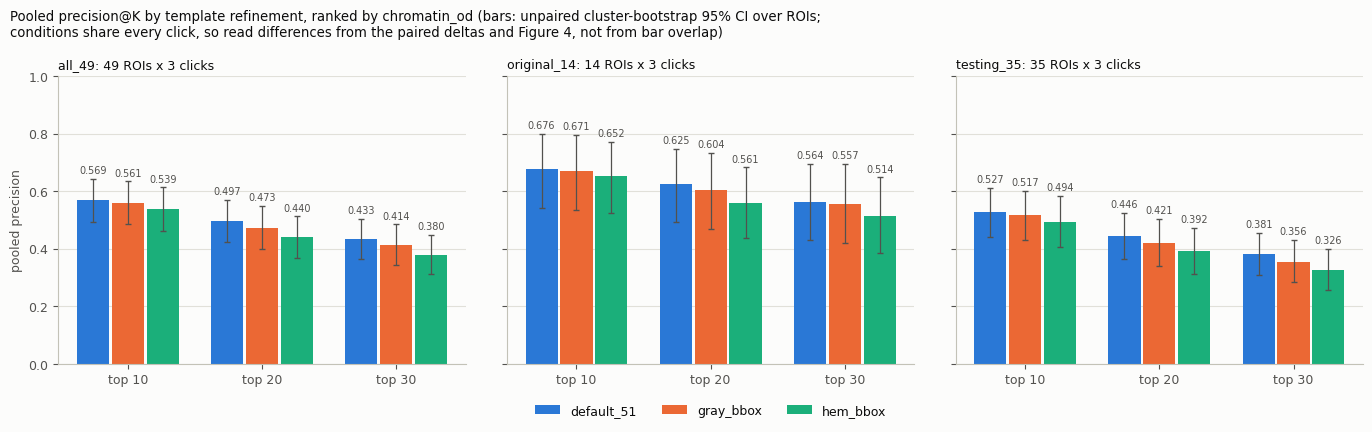

In [15]:
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

SURFACE, INK, INK_2, MUTED, GRID, AXIS = '#fcfcfb', '#0b0b0b', '#52514e', '#898781', '#e1e0d9', '#c3c2b7'
COND_COLORS = {'default_51': '#2a78d6', 'gray_bbox': '#eb6834', 'hem_bbox': '#1baf7a'}  # reference categorical slots 1-3
OUTCOME_COLORS = {'wins': '#2a78d6', 'losses': '#e34948', 'ties': '#c3c2b7'}
DIVERGING = LinearSegmentedColormap.from_list('red_gray_blue', ['#e34948', '#f0efec', '#2a78d6'])
plt.rcParams.update({'figure.facecolor': SURFACE, 'axes.facecolor': SURFACE, 'savefig.facecolor': SURFACE, 'axes.edgecolor': AXIS, 'axes.labelcolor': INK_2, 'axes.titlecolor': INK, 'xtick.color': INK_2, 'ytick.color': INK_2, 'text.color': INK, 'axes.spines.top': False, 'axes.spines.right': False, 'font.size': 9})
DOMAIN_SHORT = {'canine cutaneous mast cell tumor': 'canine mast cell', 'canine lung cancer': 'canine lung', 'canine lymphosarcoma': 'canine lymphoma', 'canine soft tissue sarcoma': 'canine STS', 'human breast cancer': 'human breast', 'human melanoma': 'human melanoma', 'human neuroendocrine tumor': 'human NET'}

# Figure 1 -- pooled precision per condition at each K, with cluster-bootstrap 95% CIs, per subset
fig, axes = plt.subplots(1, len(SUBSETS), figsize=(4.6 * len(SUBSETS), 4.4), sharey=True)
x = np.arange(len(BUDGETS))
width = 0.24
for ax, subset in zip(axes, SUBSETS):
    for i, condition in enumerate(CONDITIONS):
        b = BOOT[(BOOT['subset'] == subset) & (BOOT['quantity'] == 'pooled_precision') & (BOOT['condition_or_pair'] == condition)].set_index('K').loc[list(BUDGETS)]
        vals, lo, hi = b['estimate'].to_numpy(), b['ci_low'].to_numpy(), b['ci_high'].to_numpy()
        xs = x + (i - 1) * (width + 0.02)
        ax.bar(xs, vals, width, color=COND_COLORS[condition], label=condition, zorder=2)
        ax.errorbar(xs, vals, yerr=np.vstack([vals - lo, hi - vals]), fmt='none', ecolor=INK_2, elinewidth=0.9, capsize=2.5, zorder=3)
        for xi, v, top in zip(xs, vals, hi):
            ax.text(xi, top + 0.012, f'{v:.3f}', ha='center', va='bottom', fontsize=7, color=INK_2)
    ax.set_xticks(x)
    ax.set_xticklabels([f'top {k}' for k in BUDGETS])
    ax.set_ylim(0, 1)
    ax.yaxis.grid(True, color=GRID, linewidth=0.8)
    ax.set_axisbelow(True)
    ax.set_title(f"{subset}: {int(b['n_roi'].iat[0])} ROIs x {len(SEED_INDICES)} clicks", loc='left', fontsize=9)
axes[0].set_ylabel('pooled precision')
axes[1].legend(frameon=False, ncol=3, loc='upper center', bbox_to_anchor=(0.5, -0.1))
fig.suptitle(f'Pooled precision@K by template refinement, ranked by {RANK_KEY} (bars: unpaired cluster-bootstrap 95% CI over ROIs;\nconditions share every click, so read differences from the paired deltas and Figure 4, not from bar overlap)', fontsize=9.5, x=0.01, ha='left')
fig.tight_layout()
fig.savefig(f'{FIG_STEM}_pooled_precision.png', dpi=150, bbox_inches='tight')
plt.show()

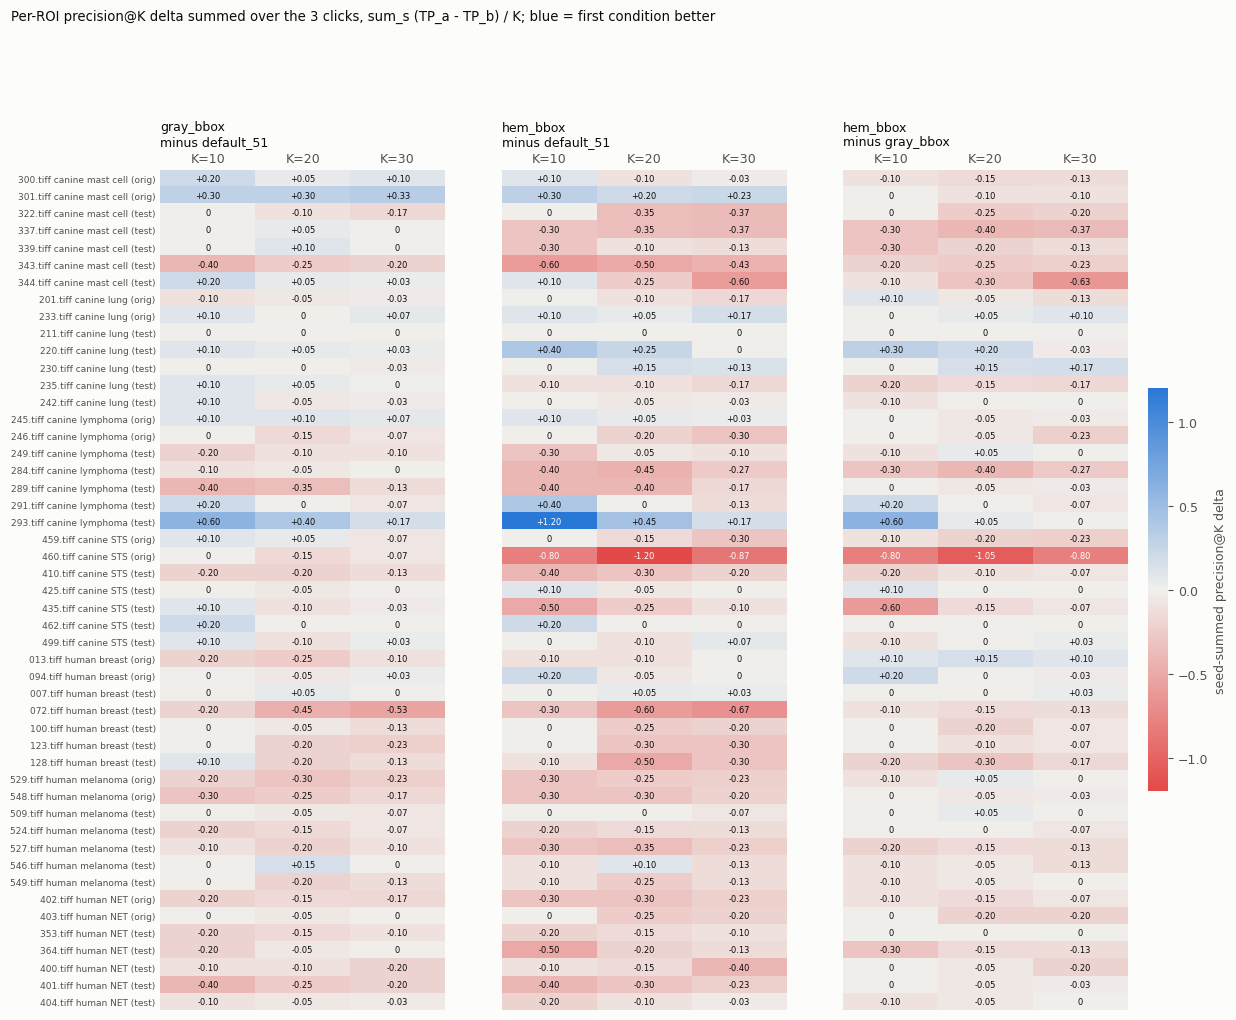

In [16]:
# Figure 2 -- per-ROI seed-summed precision delta, one panel per pair, shared colour scale
lim = max(float(DELTA_PER_ROI['delta_precision_sum'].abs().max()), 0.1)
fig, axes = plt.subplots(1, len(PAIRS), figsize=(3.6 * len(PAIRS) + 2.2, 0.19 * len(ROI_ORDER) + 1.6), sharey=True)
for ax, (a, b) in zip(axes, PAIRS):
    mat = DELTA_PER_ROI[DELTA_PER_ROI['pair'] == f'{a} - {b}'].pivot(index='file_name', columns='K', values='delta_precision_sum').loc[ROI_ORDER, list(BUDGETS)].to_numpy()
    im = ax.imshow(mat, cmap=DIVERGING, vmin=-lim, vmax=lim, aspect='auto')
    for i in range(mat.shape[0]):
        for j in range(mat.shape[1]):
            ax.text(j, i, '0' if mat[i, j] == 0 else f'{mat[i, j]:+.2f}', ha='center', va='center', fontsize=6, color=INK if abs(mat[i, j]) < 0.6 * lim else '#ffffff')
    ax.set_xticks(range(len(BUDGETS)))
    ax.set_xticklabels([f'K={k}' for k in BUDGETS])
    ax.xaxis.tick_top()
    ax.set_yticks(range(len(ROI_ORDER)))
    ax.set_yticklabels([f"{fn} {DOMAIN_SHORT.get(ROI_META.loc[fn, 'domain'], ROI_META.loc[fn, 'domain'])} ({'orig' if ROI_META.loc[fn, 'subset'] == 'original_14' else 'test'})" for fn in ROI_ORDER], fontsize=6.5)
    ax.tick_params(length=0)
    for side in ('left', 'bottom'):
        ax.spines[side].set_visible(False)
    ax.set_title(f'{a}\nminus {b}', loc='left', fontsize=9, pad=18)
cbar = fig.colorbar(im, ax=axes, fraction=0.02, pad=0.02)
cbar.set_label('seed-summed precision@K delta', color=INK_2)
cbar.outline.set_visible(False)
fig.suptitle(f'Per-ROI precision@K delta summed over the {len(SEED_INDICES)} clicks, sum_s (TP_a - TP_b) / K; blue = first condition better', fontsize=9.5, x=0.01, ha='left', y=1.0 + 0.3 / (0.19 * len(ROI_ORDER) + 1.6))
fig.savefig(f'{FIG_STEM}_roi_delta_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

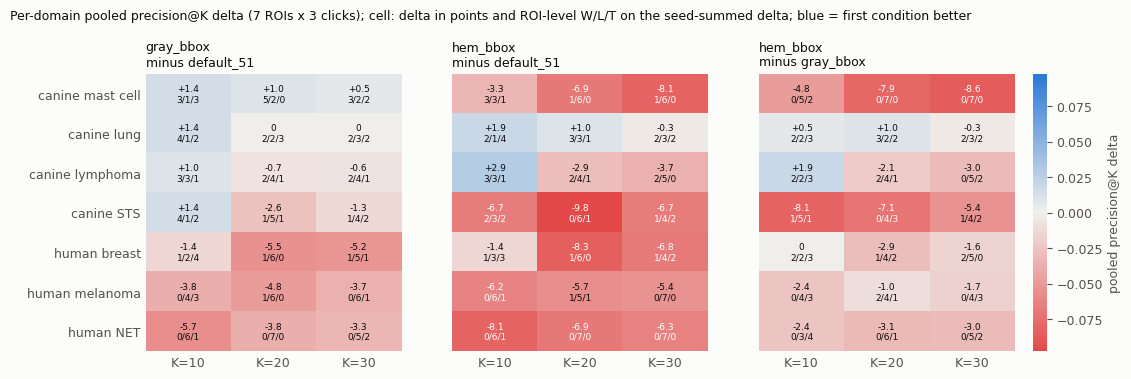

In [17]:
# Figure 3 -- per-domain pooled precision delta, one panel per pair, shared colour scale
dom = DELTA_STATS[DELTA_STATS['scope'] == 'domain']
lim = max(float(dom['pooled_delta_precision'].abs().max()), 0.02)
fig, axes = plt.subplots(1, len(PAIRS), figsize=(3.4 * len(PAIRS) + 1.6, 3.6), sharey=True)
for ax, (a, b) in zip(axes, PAIRS):
    sub = dom[dom['pair'] == f'{a} - {b}']
    mat = sub.pivot(index='group', columns='K', values='pooled_delta_precision').loc[DOMAINS, list(BUDGETS)].to_numpy()
    wlt = sub.assign(wlt=sub['wins'].astype(str) + '/' + sub['losses'].astype(str) + '/' + sub['ties'].astype(str)).pivot(index='group', columns='K', values='wlt').loc[DOMAINS, list(BUDGETS)].to_numpy()
    im = ax.imshow(mat, cmap=DIVERGING, vmin=-lim, vmax=lim, aspect='auto')
    for i in range(mat.shape[0]):
        for j in range(mat.shape[1]):
            ax.text(j, i, f"{'0' if mat[i, j] == 0 else f'{100 * mat[i, j]:+.1f}'}\n{wlt[i, j]}", ha='center', va='center', fontsize=6.5, color=INK if abs(mat[i, j]) < 0.6 * lim else '#ffffff')
    ax.set_xticks(range(len(BUDGETS)))
    ax.set_xticklabels([f'K={k}' for k in BUDGETS])
    ax.set_yticks(range(len(DOMAINS)))
    ax.set_yticklabels([DOMAIN_SHORT.get(d, d) for d in DOMAINS])
    ax.tick_params(length=0)
    for side in ('left', 'bottom'):
        ax.spines[side].set_visible(False)
    ax.set_title(f'{a}\nminus {b}', loc='left', fontsize=9)
cbar = fig.colorbar(im, ax=axes, fraction=0.03, pad=0.02)
cbar.set_label('pooled precision@K delta', color=INK_2)
cbar.outline.set_visible(False)
fig.suptitle(f'Per-domain pooled precision@K delta ({N_PER_DOMAIN} ROIs x {len(SEED_INDICES)} clicks); cell: delta in points and ROI-level W/L/T on the seed-summed delta; blue = first condition better', fontsize=9, x=0.01, ha='left', y=1.06)
fig.savefig(f'{FIG_STEM}_domain_delta.png', dpi=150, bbox_inches='tight')
plt.show()

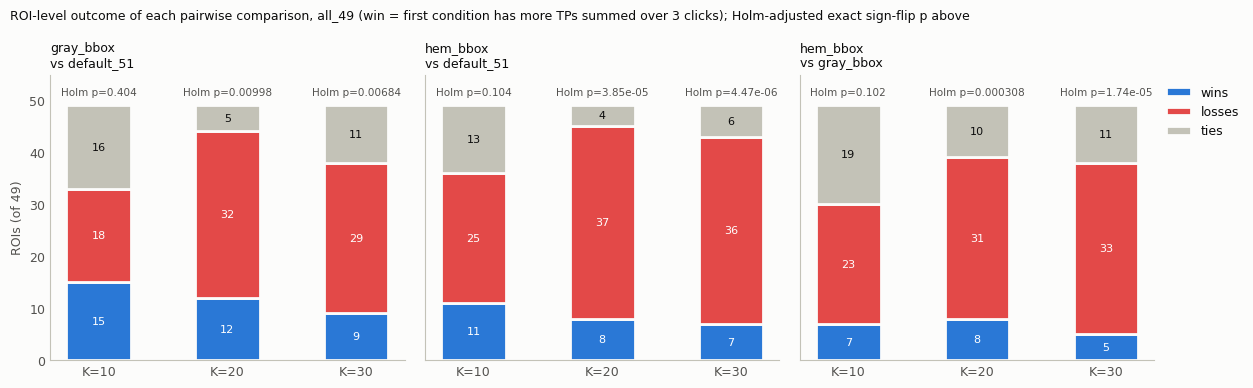

In [18]:
# Figure 4 -- ROI-level wins / losses / ties per pair, per K (all_49), Holm p above
primary = DELTA_STATS[DELTA_STATS['group'] == 'all_49']
n_roi = int(primary['n_roi'].iat[0])
fig, axes = plt.subplots(1, len(PAIRS), figsize=(4.2 * len(PAIRS), 3.9), sharey=True)
x = np.arange(len(BUDGETS))
for ax, (a, b) in zip(axes, PAIRS):
    sub = primary[primary['pair'] == f'{a} - {b}'].set_index('K').loc[list(BUDGETS)]
    bottom = np.zeros(len(BUDGETS))
    for part in ('wins', 'losses', 'ties'):
        heights = sub[part].to_numpy()
        ax.bar(x, heights, 0.5, bottom=bottom, color=OUTCOME_COLORS[part], edgecolor=SURFACE, linewidth=2, label=part, zorder=2)
        for xi, h, b0 in zip(x, heights, bottom):
            if h > 0:
                ax.text(xi, b0 + h / 2, str(int(h)), ha='center', va='center', fontsize=8, color='#ffffff' if part != 'ties' else INK)
        bottom = bottom + heights
    for xi, p in zip(x, sub['holm_p']):
        ax.text(xi, n_roi * 1.03, f'Holm p={p:.3g}', ha='center', va='bottom', fontsize=7.5, color=INK_2)
    ax.set_xticks(x)
    ax.set_xticklabels([f'K={k}' for k in BUDGETS])
    ax.set_ylim(0, n_roi * 1.12)
    ax.set_title(f'{a}\nvs {b}', loc='left', fontsize=9)
    ax.tick_params(length=0)
axes[0].set_ylabel(f'ROIs (of {n_roi})')
axes[-1].legend(frameon=False, loc='upper left', bbox_to_anchor=(1.0, 1.0))
fig.suptitle(f'ROI-level outcome of each pairwise comparison, all_49 (win = first condition has more TPs summed over {len(SEED_INDICES)} clicks); Holm-adjusted exact sign-flip p above', fontsize=9, x=0.01, ha='left')
fig.tight_layout()
fig.savefig(f'{FIG_STEM}_win_counts.png', dpi=150, bbox_inches='tight')
plt.show()

## Closing summary

Every number below is printed or tabled by a cell above. "Points" are percentage points of precision
(of recall, where marked).

**Checks.**
- *Halt checks, all passed:*
  - every list delivered 30 candidates (`n_detections` 81-100);
  - no NaN `od`, and every list is `od`-descending (441/441);
  - Gate C: one click per (ROI, seed) on 147/147, and 3 distinct clicks from 3 distinct RNG streams on 49/49;
  - at least 6 pool annotations pass the joint gate on every ROI (the minimum is 6, on `201.tiff` and
    `364.tiff`).
- *Gate A:* seed 0 on the original 14 ROIs reproduces the committed 14-ROI run exactly. That is 42/42
  per-ROI rows, and 1260/1260 top-30 rows with `od` bit-exact on all 1260.
- *Report checks:*
  - the D9 cap bound (`n_peaks = 100`) on 441/441 runs;
  - no candidate within one match radius of a click on 441/441;
  - 11 of the 441 runs removed no self-hit (the template's own peak did not survive to the post-NMS
    list). The empty annulus shows nothing near those clicks survived either.
- *Gate B:*
  - 17 (ROI, click, pair) cases cut the same template: 11 `gray_bbox = default_51`, 6
    `hem_bbox = gray_bbox`.
  - The `int(round())` geometry test and the template-pixel SHA-1 agree on 17/17.
  - All 17 return the identical top-30 list and TP counts, including the three sub-pixel centre offsets
    (0.5, 0.5 and 0.707 px). So the float-centre self-hit disc caused no divergence in this run.

**Pooled precision, `all_49`** (147 clicks per cell):

| K | `default_51` | `gray_bbox` | `hem_bbox` |
|---|---|---|---|
| 10 | 0.5694 | 0.5612 | 0.5395 |
| 20 | 0.4969 | 0.4735 | 0.4405 |
| 30 | 0.4331 | 0.4136 | 0.3798 |

The order `default_51 > gray_bbox > hem_bbox` holds at every K, and within `all_49` it holds separately
for each of the three click indices at every K (descriptive).

**Paired deltas, `all_49`** (49 ROIs; the delta is `a - b` summed over each ROI's 3 clicks). "D5
criterion" is D5's CI-and-majority clause: the bootstrap verdict, then its robustness label.

| pair | K | pooled delta (pts) | bootstrap 95% CI (pts) | t 95% CI (pts) | W/L/T | exact p | Holm p | D5 criterion |
|---|---|---|---|---|---|---|---|---|
| `gray_bbox - default_51` | 10 | -0.82 | [-2.52, +0.95] | [-2.59, +0.96] | 15/18/16 | 0.40 | 0.40 | no; not met |
| | 20 | -2.35 | [-3.78, -0.92] | [-3.81, -0.88] | 12/32/5 | 0.0025 | 0.0100 | yes; met |
| | 30 | -1.95 | [-3.11, -0.79] | [-3.15, -0.75] | 9/29/11 | 0.0014 | 0.0068 | yes; met |
| `hem_bbox - default_51` | 10 | -2.99 | [-5.78, +0.00] | [-5.97, -0.02] | 11/25/13 | 0.052 | 0.10 | no; **borderline** |
| | 20 | -5.65 | [-8.06, -3.37] | [-8.06, -3.24] | 8/37/4 | 5.5e-6 | 3.9e-5 | yes; met |
| | 30 | -5.33 | [-7.30, -3.47] | [-7.33, -3.33] | 7/36/6 | 5.0e-7 | 4.5e-6 | yes; met |
| `hem_bbox - gray_bbox` | 10 | -2.18 | [-4.15, -0.34] | [-4.15, -0.21] | 7/23/19 | 0.034 | 0.10 | no (23/49 is not a majority); not met |
| | 20 | -3.30 | [-5.20, -1.73] | [-5.11, -1.49] | 8/31/10 | 5.1e-5 | 3.1e-4 | yes; met |
| | 30 | -3.38 | [-5.01, -1.97] | [-4.96, -1.80] | 5/33/11 | 2.2e-6 | 1.7e-5 | yes; met |

Ties don't limit these tests: the largest `min_attainable_p` is 1.9e-9 in `all_49` (at
`hem_bbox - gray_bbox`, K = 10) and 4.8e-7 in `testing_35`. The Monte Carlo sign-flip agrees with the
exact convolution on 90/90 tests, with a maximum absolute difference of 1.85e-3.

**The plain answer: the template refinement changes precision at K = 20 and K = 30. At K = 10 no
contrast is resolved under precision@K pooling, and `hem_bbox`'s K = 10 cost does resolve under the
post-hoc recall@K weighting.**
- *K = 20 and 30.* All three contrasts resolve: Holm p <= 0.01, and D5's CI-and-majority criterion is
  met under both intervals.
  - `hem_bbox` costs 5.3-5.7 points against `default_51` and 3.3-3.4 against `gray_bbox`.
  - `gray_bbox`, the production template (D8), costs 1.95-2.35 points against the untightened 51 px box.
    - *Scope.* Both templates are cut at the same click, so this is the cost of the template alone. For
      a 51 px box that would also skip the Otsu gate, see the caveats.
    - *It is the least robust of the six.* The cost sits in the human domains, and under the
      worst-of-3-clicks reading its Holm p is 0.051 and 0.061 (both below).
- *K = 10.* No contrast survives Holm on precision@K.
  - `hem_bbox - default_51`: the bootstrap CI's upper end sits at 0 (2.53% of resamples are at or above
    0), while the t interval [-5.97, -0.02] excludes 0. With 25/49 ROIs in its direction, the D5
    criterion is borderline, not "not met".
  - `hem_bbox - gray_bbox`: the CI excludes 0, but only 23 of 49 ROIs move in its direction.
  - Under recall@K weighting, the two `hem_bbox` contrasts at K = 10 resolve: Holm p 0.0064
    (`- default_51`) and 0.0095 (`- gray_bbox`) in `all_49`, and 0.013 and 0.013 in `testing_35`. W/L/T
    is identical under both weightings; recall@K weights dense ROIs less. `gray_bbox - default_51` at
    K = 10 is unresolved under both (Holm p 0.40 and 0.075).
  - So the data don't support "no effect at K = 10". They support "not resolved under precision@K
    pooling".

**Contested mitoses.** 23.1-25.8% of top-K TPs are contested mitoses, spread evenly across conditions.
Every K = 20 and K = 30 resolution above keeps Holm p <= 0.05 and D5's CI-and-majority criterion
(bootstrap) under all three rules:

| pair | Holm p at K = 20 / 30: `all_mitoses` | `contested_excluded` | `contested_as_fp` |
|---|---|---|---|
| `gray_bbox - default_51` | 0.0100 / 0.0068 | 0.0102 / 0.0054 | 0.019 / 8.7e-4 |
| `hem_bbox - default_51` | 3.9e-5 / 4.5e-6 | 4.9e-4 / 4.5e-5 | 3.0e-4 / 1.1e-7 |
| `hem_bbox - gray_bbox` | 3.1e-4 / 1.7e-5 | 0.0040 / 4.5e-5 | 0.010 / 9.1e-6 |

Counting contested hits as false positives shrinks the deltas (for example, `hem_bbox - default_51`
at K = 20 goes from -5.65 to -4.52 points) but doesn't remove them. The `contested_excluded` p-values
are Monte Carlo, with a floor of 1/200,001.

**Replication.** `testing_35` (the 35 `testing_set` ROIs) is the confirmatory read: `all_49` contains
the seed-0 `original_14` draw the effect was first seen on.
- *Direction:* the pooled delta has the same sign in `testing_35` and `original_14` on 9/9 (pair, K),
  and the two subsets' CIs overlap on 9/9.
- *`testing_35` on its own:*
  - All three pairs resolve at K = 20 and 30 (Holm p 0.0325 and 0.0014 for `gray_bbox - default_51`,
    0.0014 and 2.8e-5 for `hem_bbox - default_51`, 0.0037 and 5.4e-4 for `hem_bbox - gray_bbox`). D5's
    CI-and-majority criterion is met on all six, and robustly.
  - At K = 10, no Holm p is below 0.17. `hem_bbox - gray_bbox` meets the bootstrap criterion there (CI
    [-4.38, -0.10], 18/35 ROIs), but it is borderline: 2.28% of resamples are at or above 0, within
    Monte Carlo error of 2.5%.
  - Under `contested_as_fp`, `hem_bbox - gray_bbox` at K = 20 drops to Holm p 0.065.
- *`original_14` at 3 clicks (14 ROIs: exact p, no Holm, and both intervals descriptive):*
  - `hem_bbox - default_51` at K = 20 (p 0.013) and `hem_bbox - gray_bbox` at K = 30 (p 0.018) meet
    the criterion under both intervals.
  - `hem_bbox - default_51` at K = 30 (p 0.042) and `hem_bbox - gray_bbox` at K = 20 (p 0.046) are
    borderline: the bootstrap CI excludes 0, the t interval doesn't ([-10.11, +0.11] and
    [-9.74, +1.17]).
  - `gray_bbox - default_51` does not meet it: its CIs include 0 at every K.

  So the `gray_bbox` cost is only resolved in the larger samples: `testing_35` (Holm p 0.0325 at K = 20
  and 0.0014 at K = 30) and `all_49`.

Across the 27 subset rows, the robustness label changes 4 of the bootstrap verdicts, all to
borderline, and the two intervals disagree on excluding 0 in 3.

**Post-hoc sensitivities** (added after the audit; none replaces a result above).
- *recall@K weighting* is given under K = 10 above. At K = 20 and 30 every contrast still resolves in
  `all_49` (Holm p <= 0.005), but the direction of the change differs by pair:
  - `gray_bbox - default_51` gets stronger: Holm p 0.0100 and 0.0068 become 0.0021 and 1.05e-4;
  - `hem_bbox - gray_bbox` gets weaker: 3.1e-4 and 1.7e-5 become 0.00498 and 0.00235;
  - `hem_bbox - default_51` sits at the Monte Carlo floor at both K (Holm p 4.5e-5, which is 9 times
    the smallest p 200,000 draws can return), so it can't show a change either way.
- *Worst of each ROI's 3 clicks* (`all_49`, mean worst-click precision):
  - `hem_bbox` against `default_51`: 0.3857 vs 0.451 at K = 20 (Holm p 1.6e-3) and 0.3306 vs 0.3932 at
    K = 30 (W/L/T 6/33/10, exact p 2.3e-5, Holm p 2.1e-4).
  - `hem_bbox` against `gray_bbox` at K = 30: 0.3306 vs 0.3701, Holm p 6.3e-4.
  - `gray_bbox` against `default_51`: 0.4204 vs 0.451 at K = 20 and 0.3701 vs 0.3932 at K = 30 (exact
    p 0.0086 and 0.015). Holm p is 0.051 and 0.061, so on the worst click this contrast sits at the
    edge rather than resolving.
- *Domain as the unit.* With 7 domain units, the smallest possible Holm p over 9 tests is 0.14, so no
  contrast can resolve at this unit. The observed minimum is 0.14, for both `hem_bbox` pairs at K = 30,
  where all 7 domains are negative (0/7/0). Every "resolves" above rests on the ROI being the
  exchangeable unit (D5).
- *Human vs canine* (`all_49`; descriptive, since the split was chosen after seeing the per-domain
  table):
  - `gray_bbox - default_51` is -3.65 / -4.68 / -4.07 points in the 21 human ROIs and
    +1.31 / -0.60 / -0.36 in the 28 canine ROIs at K = 10 / 20 / 30. The permutation p over the 35
    domain labelings is 0.029 / 0.057 / 0.029, where 0.029 is the floor. So the pooled -1.95 to -2.35
    describes neither group.
  - `hem_bbox - default_51` is negative in both groups at K = 20 and 30 (human -6.98 and -6.19, canine
    -4.64 and -4.68).
  - Species and scanner can't be separated here. The 28 canine ROIs are 3D Histech (21) and Aperio CS2
    (7); the 21 human ROIs are Hamamatsu XR (16), Hamamatsu S360 (3) and Aperio CS2 (2).

**Per domain** (7 ROIs each; descriptive, exact p floors of 1/64 or higher):
- *Human domains.* `gray_bbox - default_51` is negative at every K in all three human domains (breast
  -1.43 / -5.48 / -5.24, melanoma -3.81 / -4.76 / -3.65, neuroendocrine -5.71 / -3.81 / -3.33 points).
- *Canine domains.* The same contrast is +0.48 to +1.43 at every K in mast cell tumour, and
  +1.43 / 0 / 0 in lung cancer.
- *`hem_bbox - default_51`* is negative in 6 of 7 domains at K = 20 and in 7 of 7 at K = 30. Canine lung
  cancer is the one domain where no refinement moves precision by more than 1.9 points at any K.

**Worst case.**
- `211.tiff` has 0 TPs in the top 30 on all 9 of its runs. Its precision is 0 under every condition at
  every K, so it is the worst ROI in `all_49` and `testing_35`. Because every condition scores 0 there,
  it ties in every pair and contributes no sign information to any test.
- In `original_14`, the worst ROI is `245.tiff` under every condition. At K = 20 it scores 0.0833
  `default_51`, 0.1167 `gray_bbox` and 0.1000 `hem_bbox`.

**An observation, not a mechanism.** Precision falls in the same order as median template size: 51 px
(`default_51`), 39 px (`gray_bbox`) and 29 px (`hem_bbox`). The `hem_bbox` template is smaller than
`gray_bbox`'s on 135/147 clicks and never larger. Size is confounded with centre, though (median
click-to-centre offset 2.55 px for gray and 2.50 px for hem) and with which pixels count as the object.
There is no size-matched arm, so this ordering is not a dose-response.

**Caveats.**
- *Clicks come from the joint gate, not each condition's own production draw:*
  - `default_51` alone would have clicked differently on 26/147 clicks (12/42 in `original_14`,
    14/105 in `testing_35`).
  - Production `gray_bbox` alone would have clicked differently on 10/147 (6/42 and 4/105).
  - For seeds 1 and 2 this holds the earlier clicks fixed.
  - The joint gate is deliberate: sharing the click is what isolates the template. These counts say how
    often a condition's own gate would have drawn a different click, not how the conditions would
    compare on those clicks.
  - So this notebook doesn't say whether a plain 51 px box would still beat production as a pipeline,
    drawing its own click with no Otsu gate. That is the policy reading a D8 change would need. The
    audit measured it (F1 in
    `Research Logs/2026-09-17-bbox-refinement-three-way-chromatin-od-49roi-3seed-audit.md`).
- *Ties can hide disagreement.* At K = 30 in `all_49`, 6 of the 11 `gray_bbox - default_51` ties are ROIs
  whose clicks disagree and sum to 0 (4 of 6 for `hem_bbox - default_51`, 5 of 11 for
  `hem_bbox - gray_bbox`).
- *D5's full bar is not met by design.* This run applies D5's CI-and-majority clause to 3 clicks on
  49 ROIs at precision@K. D5's bar is 5 seeds on the 14 `extra_valid` ROIs at recall@K.
- *The three clicks on a ROI are drawn without replacement from its pool,* so they are distinct but not
  independent. The seed-summed ROI delta and the ROI-cluster bootstrap don't assume independence within
  an ROI.
- *`chromatin_od` ranking only;* nothing here carries over to `tm_score`.
- *D9's `MAX_PEAKS = 100`* bound on every run here, but D9 validated it with `tm_score` ranking, not
  `chromatin_od`.
- *K <= 30 only.*
- *The percentile bootstrap* with 14 ROIs (`original_14`) is coarse. Its CIs, and the t intervals beside
  them, are descriptive.
- *Shelf life (D10).* D10 replaces the 5 px self-hit filter this run used and removes
  `prod.SELF_HIT_RADIUS` and `n_self_hits`, which this notebook reads. Once D10 is applied, re-run the
  comparison on the new code rather than mixing its numbers with these.
- *Runtime* (last cell) is one wall-clock run on one machine.

In [19]:
print(f"run loop took {RUNTIME_LOOP_MIN:.1f} min (pipeline calls alone: {RESULTS['t_pipeline_s'].sum() / 60:.1f} min); notebook ran in {(time.time() - NB_T0) / 60:.1f} min")

run loop took 37.2 min (pipeline calls alone: 33.9 min); notebook ran in 37.7 min
